In [1]:
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
import os.path as op
import math
import os
import h5py

from elixer import global_config as G
G.GLOBAL_LOGGING = True
from elixer import spectrum_utilities as ESU
from elixer import catalogs


from hetdex_api.elixer_widget_cls import ElixerWidget
from hetdex_api.config import HDRconfig
from hetdex_tools.get_spec import get_spectra
from hetdex_api.shot import *
from hetdex_api.survey import FiberIndex

import inspect
import scipy.stats as stats
from astropy.table import QTable, Table, Column
import warnings
from astropy.modeling import models
from specutils.spectra import Spectrum1D, SpectralRegion
from specutils.fitting import fit_generic_continuum
from specutils.fitting.continuum import fit_continuum
from astropy.stats import biweight_location
from scipy.integrate import quad as quad
from numpy.polynomial.polynomial import polyfit
from numpy.polynomial.polynomial import polyval
from photutils.centroids import centroid_2dg, centroid_sources
from numpy import inf

from matplotlib.widgets import Button

from astropy.modeling import fitting

from tqdm.notebook import tqdm  # For Jupyter notebook
from joblib import Parallel, delayed
import seaborn as sns
from scipy.stats import probplot


import multiprocessing as mp
import time


from scipy import ndimage
from scipy.stats import median_abs_deviation
import warnings

from scipy.optimize import curve_fit, differential_evolution, minimize
from itertools import product

from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

import json

from matplotlib.backends.backend_pdf import PdfPages


In [2]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rc
import matplotlib.ticker
import matplotlib.patches as patches

%matplotlib ipympl
plt.style.use('default')
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({'font.size': 14})
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'
plt.rcParams['xtick.labelsize']= 14.0
plt.rcParams['ytick.labelsize']= 14.0
plt.rcParams['mathtext.default'] = 'rm' # All math text will be upright Roman

In [3]:
def load_variables_from_hdf5(filepath, auto_assign=True):
    """Load variables from HDF5 file"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Handle string data
            if isinstance(data, bytes):
                data = data.decode('utf-8')
            elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                data = data.astype(str)
            
            vars_dict[var_name] = data
    
    if auto_assign:
        # Automatically assign variables to global namespace
        import inspect
        frame = inspect.currentframe()
        try:
            # Get the caller's globals (the notebook's global namespace)
            caller_globals = frame.f_back.f_globals
            
            # Assign each variable to the caller's global namespace
            for var_name, var_value in vars_dict.items():
                caller_globals[var_name] = var_value
            
            print(f"Successfully loaded and assigned {len(vars_dict)} variables to global namespace")
            print("Sample variables now available:")
            for i, var_name in enumerate(vars_dict.keys()):
                if i < 3:  # Show first 3
                    print(f"  - {var_name}")
                elif i == 3:
                    print(f"  ... and {len(vars_dict) - 3} more")
                    break
                    
        finally:
            del frame
    
    return vars_dict


def load_and_assign_variables_hdf5(filepath):
    """Load variables from HDF5 and explicitly assign them using globals()"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Handle string data
            if isinstance(data, bytes):
                data = data.decode('utf-8')
            elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                data = data.astype(str)
            
            vars_dict[var_name] = data
    
    assigned_count = 0
    for var_name, var_value in vars_dict.items():
        globals()[var_name] = var_value
        assigned_count += 1
    
    print(f"Successfully loaded and assigned {assigned_count} variables")
    print("Variables are now available in the global namespace")
    
    return vars_dict


#Calculating the BH mass
def black_hole_mass(lam, wave_L_3000, FWHM, wave_L_3000_err=None, FWHM_err=None):
    """
    Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
    This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
    
    Parameters

    ----------
    lam : float
        Normalization constant, typically 1.0.
    wave_L_3000 : float or array-like
        Continuum luminosity at 3000Å in erg/s.
    FWHM : float or array-like
        Full Width at Half Maximum of the MgII line in km/s.
    wave_L_3000_err : float or array-like, optional
        Standard deviation of the continuum luminosity in erg/s.
    FWHM_err : float or array-like, optional
        Standard deviation of the FWHM in km/s.
        
    Returns
    -------
    M_bh_per_solar : float or array-like
        Black hole mass in units of solar masses.
    M_bh_per_solar_err : float or array-like or None
        Standard deviation of the black hole mass in solar masses.
        Returns None if both input errors are None.
    
    Notes
    -----
    The error propagation uses the standard formula for error propagation:
    For a function f(x,y) = A * x^a * y^b, the relative error is:
    σ_f/f = sqrt((a*σ_x/x)^2 + (b*σ_y/y)^2)
    
    References
    ----------
    Based on the calibration from McLure & Dunlop (2004) and Vestergaard & Peterson (2006).
    """
    # Convert input to numpy arrays if they aren't already
    wave_L_3000 = np.asarray(wave_L_3000)
    FWHM = np.asarray(FWHM)
    
    # Process input errors
    if wave_L_3000_err is not None:
        wave_L_3000_err = np.asarray(wave_L_3000_err)

    if FWHM_err is not None:
        FWHM_err = np.asarray(FWHM_err)
    
    # Compute black hole mass
    xx = lam * wave_L_3000  # erg/s
    xxx = xx / (10**7)  # watts (conversion from erg/s to watts)
    
    # Exponents in the formula
    power_lum = 0.47
    power_fwhm = 2.0
    
    # Calculate black hole mass
    M_bh_per_solar = 3.37 * ((xxx / 10**37)**power_lum) * (FWHM**power_fwhm)
    
    # If no errors are provided, return only the mass
    if wave_L_3000_err is None and FWHM_err is None:
        return M_bh_per_solar, None
    
    # Error propagation
    # Initialize error array with zeros
    M_bh_per_solar_err = np.zeros_like(M_bh_per_solar, dtype=float)
    
    # For elements where both errors are provided
    mask_both = np.logical_and(
        np.logical_and(wave_L_3000_err is not None, FWHM_err is not None),
        np.logical_and(wave_L_3000_err > 0, FWHM_err > 0)
    )
    
    # For elements where only luminosity error is provided
    mask_lum_only = np.logical_and(
        np.logical_and(wave_L_3000_err is not None, FWHM_err is None),
        wave_L_3000_err > 0
    )
    
    # For elements where only FWHM error is provided
    mask_fwhm_only = np.logical_and(
        np.logical_and(wave_L_3000_err is None, FWHM_err is not None),
        FWHM_err > 0
    )
    
    # Calculate relative errors for each component
    if np.any(mask_both) or np.any(mask_lum_only):
        # Relative error contribution from luminosity
        rel_err_lum = power_lum * (wave_L_3000_err / wave_L_3000)
    
    if np.any(mask_both) or np.any(mask_fwhm_only):
        # Relative error contribution from FWHM
        rel_err_fwhm = power_fwhm * (FWHM_err / FWHM)
    
    # Calculate total relative error and convert to absolute error
    if np.any(mask_both):
        rel_err_total = np.sqrt(rel_err_lum**2 + rel_err_fwhm**2)
        M_bh_per_solar_err = M_bh_per_solar * rel_err_total
    elif np.any(mask_lum_only):
        M_bh_per_solar_err = M_bh_per_solar * rel_err_lum
    elif np.any(mask_fwhm_only):
        M_bh_per_solar_err = M_bh_per_solar * rel_err_fwhm
    
    return M_bh_per_solar, M_bh_per_solar_err


In [4]:
# Usage in another notebook
Table_b = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables.h5")


Successfully loaded and assigned 1316 variables to global namespace
Sample variables now available:
  - AGN_Only_Continuum_L3000_025_035
  - AGN_Only_Continuum_L3000_035_045
  - AGN_Only_Continuum_L3000_045_055
  ... and 1313 more


"""

"""
MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_025_035 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_025_035.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_045_055 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_045_055.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_055_065 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_055_065.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_065_075 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_065_075.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_075_085 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_075_085.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_085_096 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_085_096.strip('[]'), sep=' ')



MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096.strip('[]'), sep=' ')


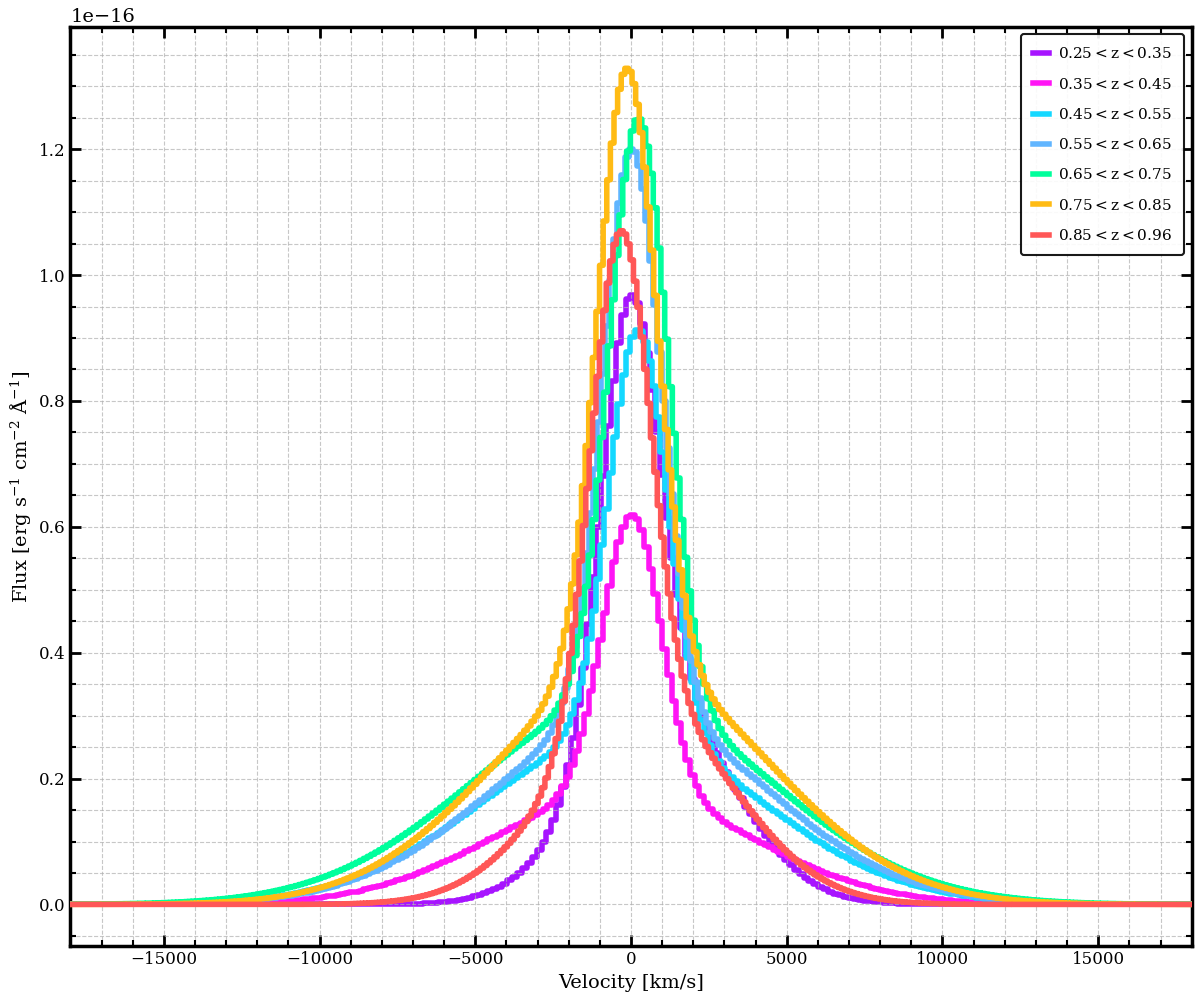

In [5]:
"""
Overplotting the MgII emission region with the continuum removed.
Unified MNRAS-style formatting to match the second code's style.
"""
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters (matching second code style)
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions (adjusted to match second code proportions)
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

# Color scheme matching second code's cool-to-warm progression
colors = {
    'z_025_035': "#a714ff",   # Purple (deep/cool)
    'z_035_045': "#ff14f5",   # Pink
    'z_045_055': "#14D8FF",   # Teal
    'z_055_065': "#60B5FF",   # Blue
    'z_065_075': "#00FF9C",   # Green
    'z_075_085': "#ffbb14",   # Orange
    'z_085_096': "#FF5757",   # Red (warm)
    'reference_lines': "black"
}

# Labels for legend (formatted for better readability, matching second code format)
redshift_labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting
datasets = [
    ('z_025_035', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_025_035, 
     redshift_labels[0]),
    ('z_035_045', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045, 
     redshift_labels[1]),
    ('z_045_055', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_045_055, 
     redshift_labels[2]),
    ('z_055_065', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_055_065, 
     redshift_labels[3]),
    ('z_065_075', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_065_075, 
     redshift_labels[4]),
    ('z_075_085', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_075_085, 
     redshift_labels[5]),
    ('z_085_096', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_085_096, 
     redshift_labels[6])
]

# Plot each dataset
for i, (key, wave, flux, label) in enumerate(datasets):
    color = colors[key]
    
    # Plot uncertainty band (optional - currently commented out)
    # ax.fill_between(wave, flux - error, flux + error, 
    #                 color=color, alpha=0.2, zorder=i*2, 
    #                 label=f'±1σ {label}' if i == 0 else "")
    
    # Plot main spectrum line
    ax.step(wave, flux, 
            color=color, 
            linewidth=4.0, 
            linestyle="-", 
            alpha=1.0, 
            zorder=i*2+1,
            label=label)

# Reference spectral lines configuration (commented out as in original)
# reference_lines = [
#     (2799, "--", 2, r"Mg II $\lambda$2799"),
#     (2945.106, ":", 2, r"He I $\lambda$2945")
# ]

# Plot reference lines
# for wavelength, linestyle, linewidth, label in reference_lines:
#     ax.axvline(x=wavelength, 
#                color=colors['reference_lines'], 
#                linestyle=linestyle, 
#                linewidth=linewidth,
#                label=label, 
#                zorder=100)

# Configure axes labels (matching second code font sizes)
ax.set_xlabel(r"Velocity [km/s]", fontsize=14, color="black")
ax.set_ylabel(r"Flux [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]", fontsize=14, color="black")

# Configure legend with MNRAS style (simplified like second code)
legend = ax.legend(
    loc='upper right',
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=False,  # Removed shadow to match second code
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1,
    ncol=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Configure grid (matching second code style)
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters (matching second code font sizes)
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Set specific axis limits
ax.set_xlim(-18000, 18000)

# Adjust layout
plt.tight_layout(pad=0.5)

# Optional: Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Multi_Redshift_Spectra_MNRAS_Ready.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Multi_Redshift_Spectra_MNRAS_Ready.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show(block=False)


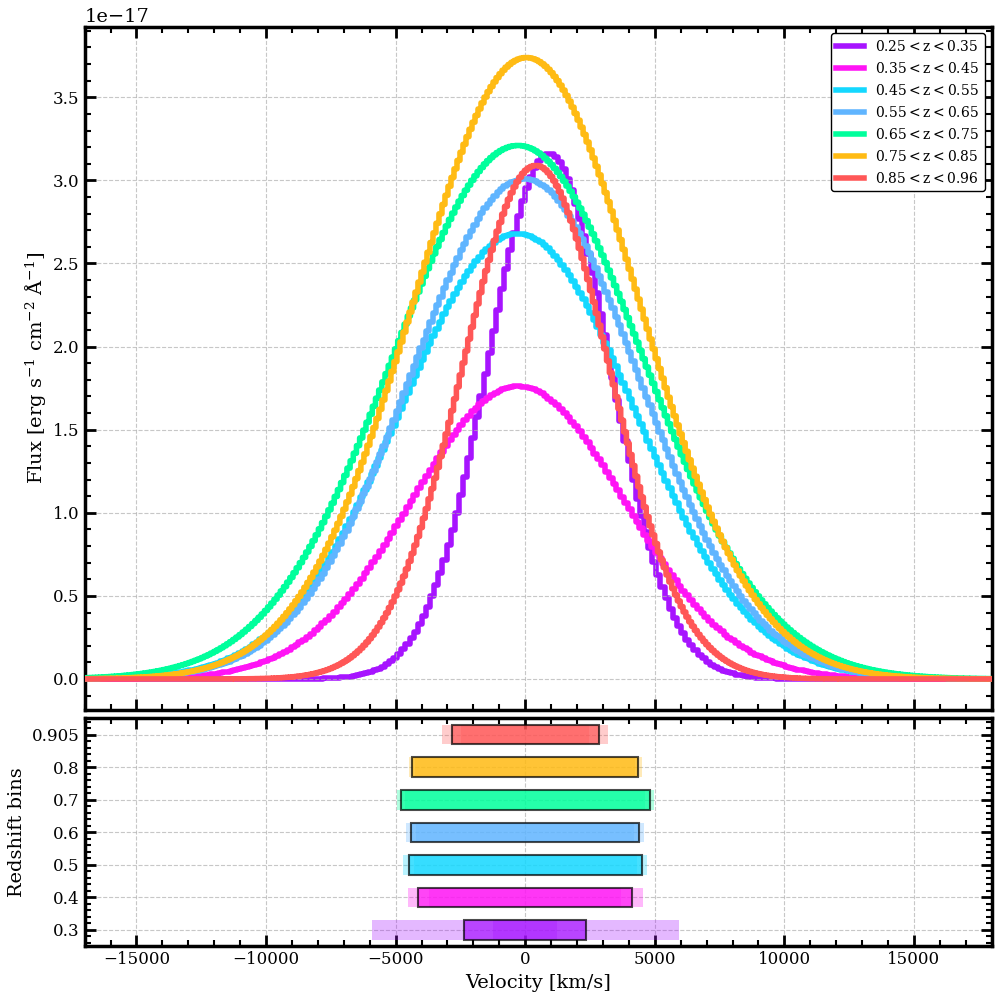

In [6]:
"""
Two-panel plot: MgII spectra (top) and FWHM analysis (bottom).
Unified MNRAS-style formatting with shared color scheme and x-axis.
"""
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with two subplots (BH mass above, luminosity below with smaller height)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), facecolor='white', 
                               gridspec_kw={'height_ratios': [3, 1]})

# Shared color scheme
colors = {
    'z_025_035': "#a714ff",   # Purple (deep/cool)
    'z_035_045': "#ff14f5",   # Pink
    'z_045_055': "#14D8FF",   # Teal
    'z_055_065': "#60B5FF",   # Blue
    'z_065_075': "#00FF9C",   # Green
    'z_075_085': "#ffbb14",   # Orange
    'z_085_096': "#FF5757",   # Red (warm)
    'reference_lines': "black"
}

# Labels for legend
redshift_labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# ============== TOP PANEL: SPECTRA ==============
# Dataset configuration for spectral plotting
datasets = [
    ('z_025_035', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035, 
     redshift_labels[0]),
    ('z_035_045', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045, 
     redshift_labels[1]),
    ('z_045_055', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055, 
     redshift_labels[2]),
    ('z_055_065', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065, 
     redshift_labels[3]),
    ('z_065_075', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075, 
     redshift_labels[4]),
    ('z_075_085', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085, 
     redshift_labels[5]),
    ('z_085_096', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096, 
     redshift_labels[6])
]

# Plot each spectrum dataset
for i, (key, wave, flux, label) in enumerate(datasets):
    color = colors[key]
    
    # Plot main spectrum line
    ax1.step(wave, flux, 
             color=color, 
             linewidth=4.0, 
             linestyle="-", 
             alpha=1.0, 
             zorder=i*2+1,
             label=label)

# Configure top panel (spectra)
ax1.set_ylabel(r"Flux [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]", fontsize=14, color="black")

# ============== BOTTOM PANEL: FWHM ==============
# FWHM data configuration
fwhm_datasets = [
    ('z_025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035),
    ('z_035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045),
    ('z_045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055),
    ('z_055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065),
    ('z_065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075),
    ('z_075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085),
    ('z_085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)
]

# Plot FWHM data as horizontal bars/shaded regions
for i, (key, fwhm_val, fwhm_err) in enumerate(fwhm_datasets):
    color = colors[key]
    
    # Convert sigma to FWHM if needed (uncomment if values are in sigma units)
    # fwhm_val_converted = fwhm_val * 2.355
    # fwhm_err_converted = fwhm_err * 2.355
    
    # Create horizontal bar showing FWHM extent
    y_pos = i + 0.5  # Vertical position for this redshift bin
    
    # Plot central FWHM as filled rectangle
    ax2.barh(y_pos, fwhm_val * 2, left=-fwhm_val, height=0.6, 
             color=color, alpha=0.7, edgecolor='black', linewidth=1.5,
             zorder=10)
    
    # Plot uncertainty as lighter shaded region extending beyond main bar
    if fwhm_err > 0:
        total_width_lower = (fwhm_val - fwhm_err) * 2
        total_width_upper = (fwhm_val + fwhm_err) * 2
        
        # Lower uncertainty (narrower bar)
        ax2.barh(y_pos, total_width_lower, left=-(fwhm_val - fwhm_err), height=0.6,
                color=color, alpha=0.3, edgecolor=None, zorder=5)
        
        # Upper uncertainty (wider bar)
        ax2.barh(y_pos, total_width_upper, left=-(fwhm_val + fwhm_err), height=0.6,
                color=color, alpha=0.3, edgecolor=None, zorder=5)

# Configure bottom panel (FWHM)
ax2.set_xlabel(r"Velocity [km/s]", fontsize=14, color="black")
ax2.set_ylabel(r"Redshift bins", fontsize=14, color="black")

# Set y-axis to show redshift bin labels
ax2.set_ylim(0, len(fwhm_datasets))
ax2.set_yticks([i + 0.5 for i in range(len(fwhm_datasets))])
ax2.set_yticklabels([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905])

# ============== SHARED X-AXIS CONFIGURATION ==============
# Set the same x-axis limits for both panels
shared_xlim = (-17000, 18000)
ax1.set_xlim(shared_xlim)
ax2.set_xlim(shared_xlim)

# ============== SHARED FORMATTING ==============
# Apply formatting to both panels
for ax in [ax1, ax2]:
    # Configure grid
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    
    # Set minor ticks
    ax.minorticks_on()
    
    # Configure spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide x-axis labels on top panel (since bottom panel shows them)
ax1.set_xticklabels([])

# Add legend to top panel
ax1.legend(loc='upper right', fontsize=10, ncol=1)

# Adjust layout
plt.tight_layout(pad=0.5)

fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Broad_MgII_FWHM.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show(block=False)


## <font color='#00879E' size=5 >Getting the Black hole masses - Uniform Narrow Sigma - FeII Removed </font>

In [7]:
"""
For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_Mean_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_Mean_SD_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_Mean_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_Mean_SD_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_Mean_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_Mean_SD_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_Mean_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_Mean_SD_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_Mean_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_Mean_SD_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_Mean_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_Mean_SD_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_Mean_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_Mean_SD_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)

########################################################################################################################################################################################################################################################################################
############################################################################################################################################
############################################

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_SD_025_035 = black_hole_mass(3000, Luminosities_Binned_Data_Mean_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035, 
                                                                                                                                                                        Luminosities_Binned_Data_Mean_SD_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_035_045 = black_hole_mass(3000, Luminosities_Binned_Data_Mean_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045, 
                                                                                                                                                                        Luminosities_Binned_Data_Mean_SD_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_045_055 = black_hole_mass(3000, Luminosities_Binned_Data_Mean_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055, 
                                                                                                                                                                        Luminosities_Binned_Data_Mean_SD_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_055_065 = black_hole_mass(3000, Luminosities_Binned_Data_Mean_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065, 
                                                                                                                                                                        Luminosities_Binned_Data_Mean_SD_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_065_075 = black_hole_mass(3000, Luminosities_Binned_Data_Mean_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075, 
                                                                                                                                                                        Luminosities_Binned_Data_Mean_SD_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_075_085 = black_hole_mass(3000, Luminosities_Binned_Data_Mean_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085, 
                                                                                                                                                                        Luminosities_Binned_Data_Mean_SD_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_085_096 = black_hole_mass(3000, Luminosities_Binned_Data_Mean_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096, 
                                                                                                                                                                        Luminosities_Binned_Data_Mean_SD_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)


Dual subplot chart created successfully!
AGN Only luminosities: [3.13725176e+40 2.96475954e+40 1.73568633e+40 2.53370985e+40
 2.75577883e+40 1.90123577e+40 2.30623507e+40]
All sources luminosities: [5.78063165e+40 5.23130531e+40 3.29207122e+40 4.58905673e+40
 4.31973896e+40 3.99893179e+40 3.91948105e+40]
AGN Only masses: [17992084.17302223 54223789.03547764 50217305.11467282 57351922.0767627
 71002593.78583637 49246950.07168811 22851203.91331448]
All sources masses: [23979032.63939344 70811132.49111554 67844157.29478768 75821479.43963744
 87705007.87381153 69846734.78735241 29319856.06652223]


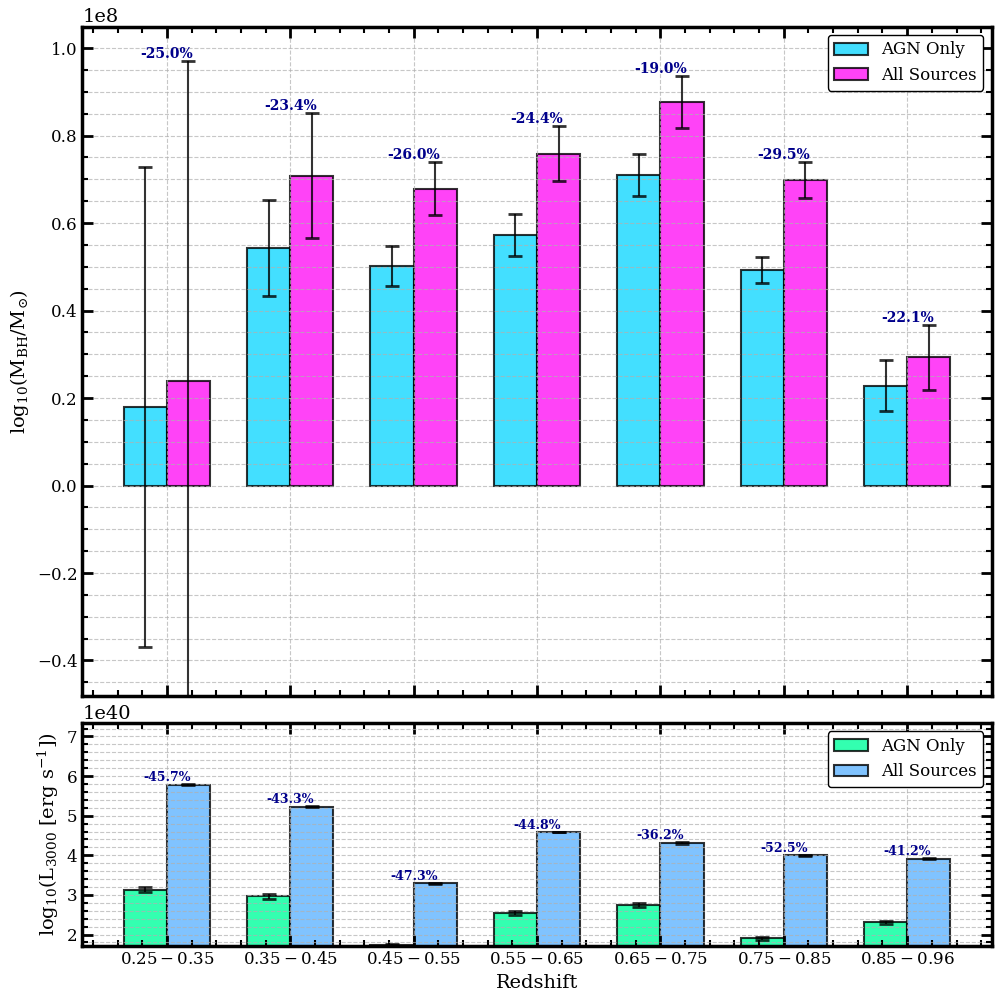

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with two subplots (BH mass above, luminosity below with smaller height)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), facecolor='white', 
                               gridspec_kw={'height_ratios': [3, 1]})

# Define redshift bin labels and positions
redshift_labels = [
    r'$0.25-0.35$',
    r'$0.35-0.45$',
    r'$0.45-0.55$',
    r'$0.55-0.65$',
    r'$0.65-0.75$',
    r'$0.75-0.85$',
    r'$0.85-0.96$'
]

# X positions for the bars
x_pos = np.arange(len(redshift_labels))
bar_width = 0.35

# Color scheme for specific redshift bins
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Colors for the plots
bh_agn_only_color = colors['045_055']    # Teal for BH AGN Only
bh_all_color = colors['035_045']         # Pink for BH All Sources
lum_agn_only_color = colors['065_075']   # Green for Luminosity AGN Only  
lum_all_color = colors['055_065']        # Blue for Luminosity All Sources

# ============================================================================
# LUMINOSITY DATA
# ============================================================================
# AGN Only luminosity data
agn_only_luminosities = np.array([
    Luminosities_AGN_Only_Binned_Data_Mean_025_035,
    Luminosities_AGN_Only_Binned_Data_Mean_035_045,
    Luminosities_AGN_Only_Binned_Data_Mean_045_055,
    Luminosities_AGN_Only_Binned_Data_Mean_055_065,
    Luminosities_AGN_Only_Binned_Data_Mean_065_075,
    Luminosities_AGN_Only_Binned_Data_Mean_075_085,
    Luminosities_AGN_Only_Binned_Data_Mean_085_096

])

# All sources luminosity data
all_luminosities = np.array([
     Luminosities_Binned_Data_Mean_025_035,
     Luminosities_Binned_Data_Mean_035_045,
     Luminosities_Binned_Data_Mean_045_055,
     Luminosities_Binned_Data_Mean_055_065,
     Luminosities_Binned_Data_Mean_065_075,
     Luminosities_Binned_Data_Mean_075_085,
     Luminosities_Binned_Data_Mean_085_096

])

# Luminosity error bars
agn_only_lum_errors = np.array([
    Luminosities_AGN_Only_Binned_Data_Mean_SD_025_035,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_035_045,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_045_055,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_055_065,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_065_075,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_075_085,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_085_096

])

all_lum_errors = np.array([
    Luminosities_Binned_Data_Mean_SD_025_035,
    Luminosities_Binned_Data_Mean_SD_035_045,
    Luminosities_Binned_Data_Mean_SD_045_055,
    Luminosities_Binned_Data_Mean_SD_055_065,
    Luminosities_Binned_Data_Mean_SD_065_075,
    Luminosities_Binned_Data_Mean_SD_075_085,
    Luminosities_Binned_Data_Mean_SD_085_096

])

# ============================================================================
# BLACK HOLE MASS DATA 
# ============================================================================
# Your actual black hole mass data
agn_only_masses = np.array([
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096

])

all_masses = np.array([
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096

])

# Error bars using your SD values
agn_only_errors = np.array([
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096

])

all_errors = np.array([
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_SD_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_085_096
])

# ============================================================================
# TOP SUBPLOT: BLACK HOLE MASS
# ============================================================================
# Create grouped bars for black hole mass
bars1_bh = ax1.bar(x_pos - bar_width/2, agn_only_masses, bar_width, 
                   color=bh_agn_only_color, alpha=0.8, label='AGN Only',
                   edgecolor='black', linewidth=1.5)

bars2_bh = ax1.bar(x_pos + bar_width/2, all_masses, bar_width,
                   color=bh_all_color, alpha=0.8, label='All Sources',
                   edgecolor='black', linewidth=1.5)

# Add error bars for black hole mass
ax1.errorbar(x_pos - bar_width/2, agn_only_masses, yerr=agn_only_errors,
             fmt='none', ecolor='black', capsize=5, capthick=2, 
             elinewidth=1.5, alpha=0.8)

ax1.errorbar(x_pos + bar_width/2, all_masses, yerr=all_errors,
             fmt='none', ecolor='black', capsize=5, capthick=2,
             elinewidth=1.5, alpha=0.8)

# Add percentage difference text above each group
for i in range(len(x_pos)):
    # Calculate percentage change: (AGN - All) / All * 100
    pct_change = ((agn_only_masses[i] - all_masses[i]) / all_masses[i]) * 100
    
    # Position text above the taller bar
    y_pos = max(agn_only_masses[i] + agn_only_errors[i], 
                all_masses[i] + all_errors[i]) + 0.05
    
    # Format: positive values with +, negative values show -
    sign = "+" if pct_change >= 0 else ""
    ax1.text(x_pos[i], y_pos, f'{sign}{pct_change:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             color='darkred' if pct_change > 0 else 'darkblue')

# Configure black hole mass subplot
ax1.set_ylabel(r'log$_{10}$(M$_{\mathrm{BH}}$/M$_{\odot}$)', fontsize=14, color='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([])  # No x-labels on top plot
ax1.legend(loc='upper right', fontsize=12, framealpha=1.0)

# Configure grid for black hole mass
ax1.grid(visible=True, which='both', axis='y', 
         linestyle='--', alpha=0.7, zorder=-10)
ax1.minorticks_on()

# Configure spine thickness for black hole mass subplot
for spine in ax1.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters for black hole mass
ax1.tick_params(axis='both', which='major', labelsize=12,
                length=8, width=2.0, direction='in')
ax1.tick_params(axis='both', which='minor', labelsize=10,
                length=4, width=1.5, direction='in')
ax1.tick_params(top=True, right=True)

# Adjust y-limits for black hole mass to accommodate error bars and text
ymin_bh = min(np.min(agn_only_masses - agn_only_errors), 
              np.min(all_masses - all_errors)) * 0.98
ymax_bh = max(np.max(agn_only_masses + agn_only_errors), 
              np.max(all_masses + all_errors)) * 1.08  # Extra space for percentage text
ax1.set_ylim(ymin_bh, ymax_bh)

# ============================================================================
# BOTTOM SUBPLOT: LUMINOSITY
# ============================================================================
# Create grouped bars for luminosity
bars1_lum = ax2.bar(x_pos - bar_width/2, agn_only_luminosities, bar_width, 
                    color=lum_agn_only_color, alpha=0.8, label='AGN Only',
                    edgecolor='black', linewidth=1.5)

bars2_lum = ax2.bar(x_pos + bar_width/2, all_luminosities, bar_width,
                    color=lum_all_color, alpha=0.8, label='All Sources',
                    edgecolor='black', linewidth=1.5)

# Add error bars for luminosity
ax2.errorbar(x_pos - bar_width/2, agn_only_luminosities, yerr=agn_only_lum_errors,
             fmt='none', ecolor='black', capsize=5, capthick=2, 
             elinewidth=1.5, alpha=0.8)

ax2.errorbar(x_pos + bar_width/2, all_luminosities, yerr=all_lum_errors,
             fmt='none', ecolor='black', capsize=5, capthick=2,
             elinewidth=1.5, alpha=0.8)

# Add percentage difference text above each group
for i in range(len(x_pos)):
    # Calculate percentage change: (AGN - All) / All * 100
    pct_change = ((agn_only_luminosities[i] - all_luminosities[i]) / all_luminosities[i]) * 100
    
    # Position text above the taller bar
    y_pos = max(agn_only_luminosities[i] + agn_only_lum_errors[i], 
                all_luminosities[i] + all_lum_errors[i]) + 0.02
    
    # Format: positive values with +, negative values show -
    sign = "+" if pct_change >= 0 else ""
    ax2.text(x_pos[i], y_pos, f'{sign}{pct_change:.1f}%', 
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color='darkred' if pct_change > 0 else 'darkblue')

# Configure luminosity subplot
ax2.set_xlabel('Redshift', fontsize=14, color='black')
ax2.set_ylabel(r'log$_{10}$(L$_{3000}$ [erg s$^{-1}$])', fontsize=14, color='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(redshift_labels)
ax2.legend(loc='upper right', fontsize=12, framealpha=1.0)

# Configure grid for luminosity
ax2.grid(visible=True, which='both', axis='y', 
         linestyle='--', alpha=0.7, zorder=-10)
ax2.minorticks_on()

# Configure spine thickness for luminosity subplot
for spine in ax2.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters for luminosity
ax2.tick_params(axis='both', which='major', labelsize=12,
                length=8, width=2.0, direction='in')
ax2.tick_params(axis='both', which='minor', labelsize=10,
                length=4, width=1.5, direction='in')
ax2.tick_params(top=True, right=True)

# Adjust y-limits for luminosity to accommodate error bars and text
ymin_lum = min(np.min(agn_only_luminosities - agn_only_lum_errors), 
               np.min(all_luminosities - all_lum_errors)) * 0.998
ymax_lum = max(np.max(agn_only_luminosities + agn_only_lum_errors), 
               np.max(all_luminosities + all_lum_errors)) * 1.008  # Extra space for percentage text
ax2.set_ylim(ymin_lum, ymax_lum +1.5e40)

# ============================================================================
# FINAL LAYOUT AND DISPLAY
# ============================================================================
# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.15)  # Slightly more space for percentage text

# Adjust overall layout
plt.tight_layout(pad=0.5)

# Print data summary
print("Dual subplot chart created successfully!")
print(f"AGN Only luminosities: {agn_only_luminosities}")
print(f"All sources luminosities: {all_luminosities}")
print(f"AGN Only masses: {agn_only_masses}")
print(f"All sources masses: {all_masses}")


fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Change_Luminosities_BH_Mass.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')


# Show the figure
plt.show(block=False)


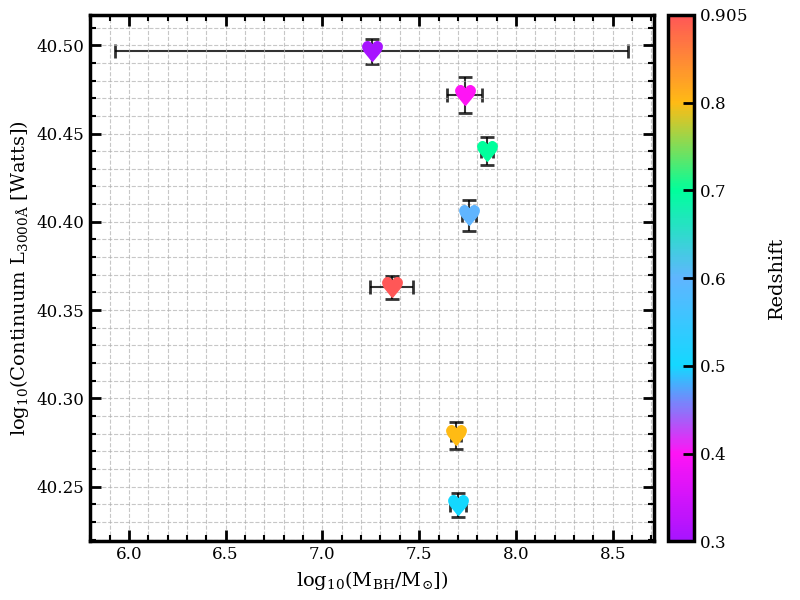

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]


# Dataset configuration for plotting
datasets = [
    ('025_035', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035), 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_025_035), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035*np.log(10)), 
     Luminosities_AGN_Only_Binned_Data_Mean_SD_025_035 / ( Luminosities_AGN_Only_Binned_Data_Mean_025_035 * np.log(10))),
    ('035_045', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_035_045), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045*np.log(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_035_045 / ( Luminosities_AGN_Only_Binned_Data_Mean_035_045 * np.log(10))),
    ('045_055', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_045_055), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055*np.log(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_045_055 / ( Luminosities_AGN_Only_Binned_Data_Mean_045_055 * np.log(10))),
    ('055_065', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_055_065), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065*np.log(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_055_065 / ( Luminosities_AGN_Only_Binned_Data_Mean_055_065 * np.log(10))),
    ('065_075', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_065_075), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075*np.log(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_065_075 / ( Luminosities_AGN_Only_Binned_Data_Mean_065_075 * np.log(10))),
    ('075_085', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_075_085), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085*np.log(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_075_085 / ( Luminosities_AGN_Only_Binned_Data_Mean_075_085 * np.log(10))),
    ('085_096', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_085_096), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096*np.log(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_085_096 / (  Luminosities_AGN_Only_Binned_Data_Mean_085_096* np.log(10)))
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$])", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


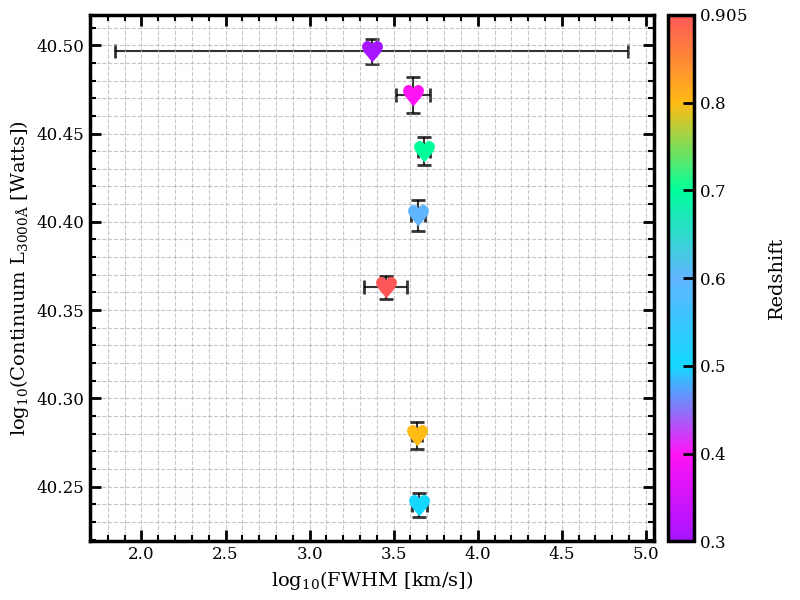

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (using broad component data)
datasets = [
    ('025_035', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035), 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_025_035), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10)), 
     Luminosities_AGN_Only_Binned_Data_Mean_SD_025_035 / (Luminosities_AGN_Only_Binned_Data_Mean_025_035 * np.log(10))),
    ('035_045', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_035_045), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_035_045 / (Luminosities_AGN_Only_Binned_Data_Mean_035_045 * np.log(10))),
    ('045_055', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_045_055), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_045_055 / (Luminosities_AGN_Only_Binned_Data_Mean_045_055 * np.log(10))),
    ('055_065', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_055_065), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_055_065 / (Luminosities_AGN_Only_Binned_Data_Mean_055_065 * np.log(10))),
    ('065_075', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_065_075), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_065_075 / (Luminosities_AGN_Only_Binned_Data_Mean_065_075 * np.log(10))),
    ('075_085', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_075_085), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_075_085 / (Luminosities_AGN_Only_Binned_Data_Mean_075_085 * np.log(10))),
    ('085_096', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_085_096), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_085_096 / (Luminosities_AGN_Only_Binned_Data_Mean_085_096 * np.log(10)))
]
         

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


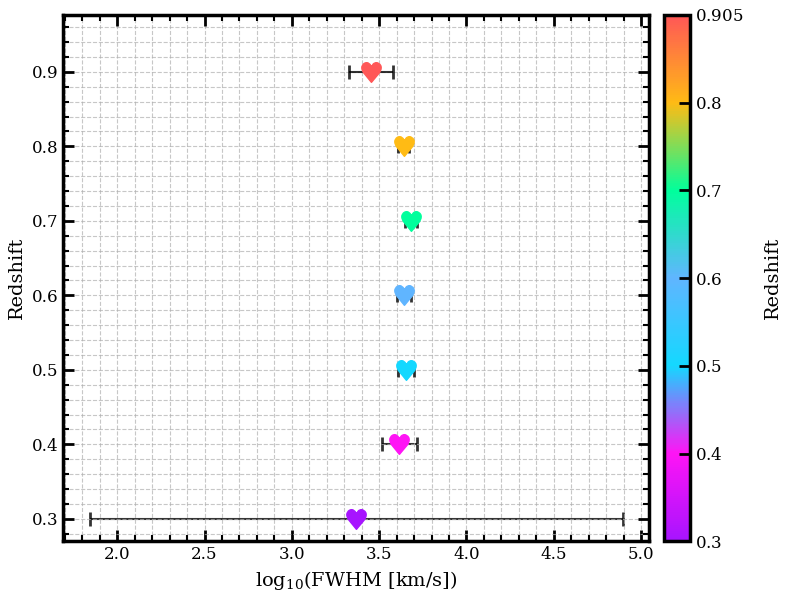

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-values for each redshift bin (fixed positions)
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (redshift vs FWHM with fixed y-positions)
datasets = [
    ('025_035', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
     0.3, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10)), 
     None),  # No y-error for fixed positions
    ('035_045', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     0.4, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10)),
     None),
    ('045_055', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     0.5, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10)),
     None),
    ('055_065', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     0.6, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10)),
     None),
    ('065_075', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     0.7, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10)),
     None),
    ('075_085', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     0.8, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10)),
     None),
    ('085_096', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     0.9, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)),
     None)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (only x-direction since y-positions are fixed)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,  # Will be None
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Redshift_FWHM_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Redshift_FWHM_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


## <font color='#00879E' size=5 >Getting the Black hole masses from the Luminosity Corrected data - Uniform Narrow Sigma - FeII Removed </font>

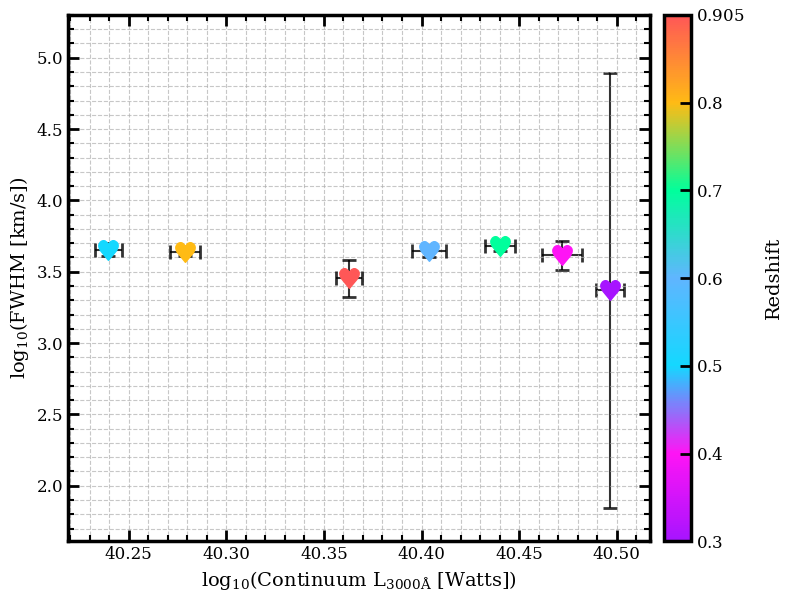

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Broad Component)
datasets = [
    ('025_035', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_025_035),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_025_035 / (Luminosities_AGN_Only_Binned_Data_Mean_025_035 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10))
     ),
    ('035_045', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_035_045),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_035_045 / (Luminosities_AGN_Only_Binned_Data_Mean_035_045 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10))
     ),
    ('045_055', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_045_055),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_045_055 / (Luminosities_AGN_Only_Binned_Data_Mean_045_055 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10))
     ),
    ('055_065', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_055_065),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_055_065 / (Luminosities_AGN_Only_Binned_Data_Mean_055_065 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10))
     ),
    ('065_075', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_065_075),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_065_075 / (Luminosities_AGN_Only_Binned_Data_Mean_065_075 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10))
     ),
    ('075_085', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_075_085),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_075_085 / (Luminosities_AGN_Only_Binned_Data_Mean_075_085 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10))
     ),
    ('085_096', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_085_096),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_085_096 / (Luminosities_AGN_Only_Binned_Data_Mean_085_096 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10))
     )
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


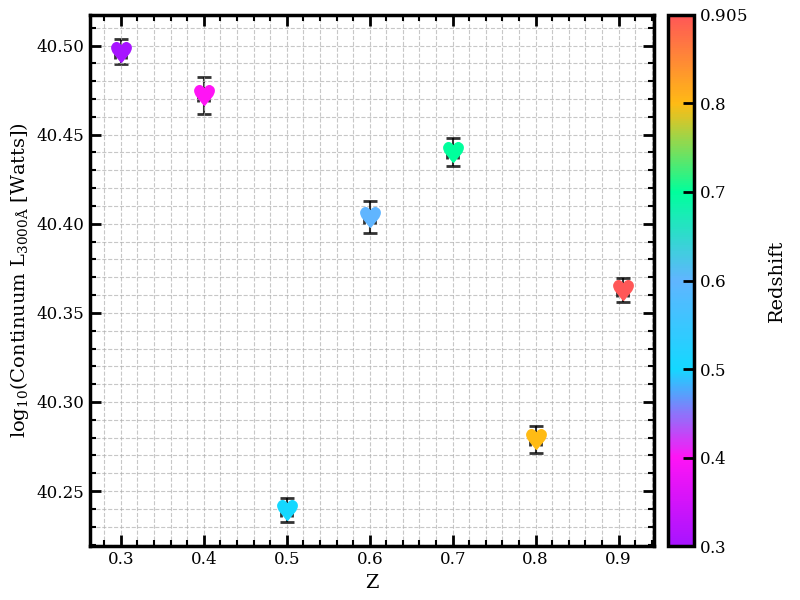

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Narrow Component)
datasets = [
    ('025_035', 
     0.3,
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_025_035),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_025_035 / ( Luminosities_AGN_Only_Binned_Data_Mean_025_035 * np.log(10))),
    ('035_045', 
     0.4,
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_035_045),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_035_045 / ( Luminosities_AGN_Only_Binned_Data_Mean_035_045 * np.log(10))),
    ('045_055', 
     0.5,
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_045_055),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_045_055 / ( Luminosities_AGN_Only_Binned_Data_Mean_045_055 * np.log(10))),
    ('055_065', 
     0.6,
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_055_065),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_055_065 / ( Luminosities_AGN_Only_Binned_Data_Mean_055_065 * np.log(10))),
    ('065_075', 
     0.7,
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_065_075),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_065_075 / ( Luminosities_AGN_Only_Binned_Data_Mean_065_075 * np.log(10))),
    ('075_085', 
     0.8,
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_075_085),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_075_085 / ( Luminosities_AGN_Only_Binned_Data_Mean_075_085 * np.log(10))),
    ('085_096', 
     0.905,
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_085_096),
     Luminosities_AGN_Only_Binned_Data_Mean_SD_085_096 / (  Luminosities_AGN_Only_Binned_Data_Mean_085_096* np.log(10)))
]

# Plot each dataset
for i, (key, x_data, y_data, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Z", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Narrow - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(40.75, 40.92)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


## <font color='#00879E' size=5 >Getting the Black hole masses Stellar mass relationship - from the Luminosity Corrected data - Uniform Narrow Sigma - FeII Removed </font>

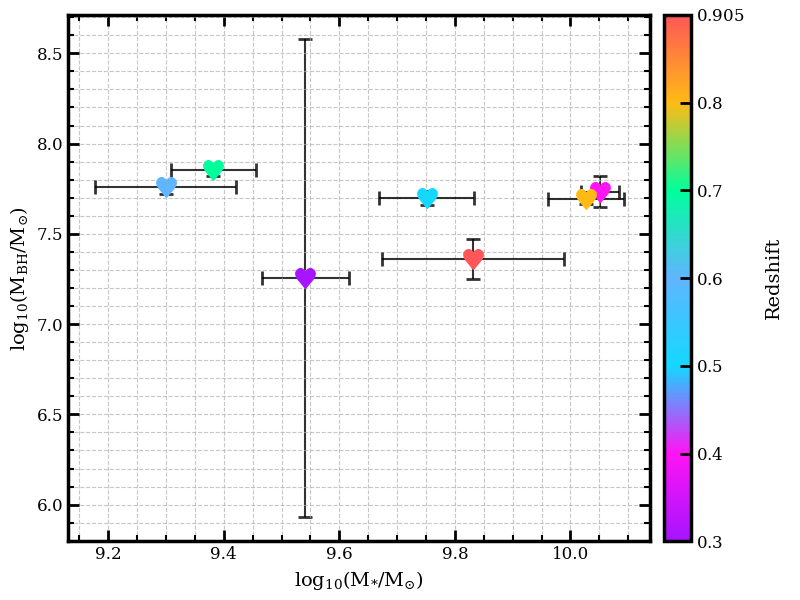

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    Stellar_Mass_Average_025_035,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035),
    Stellar_Mass_SD_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035*np.log(10))), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    Stellar_Mass_Average_035_045,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045),
    Stellar_Mass_SD_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045*np.log(10))),
    ('045_055', 
    Stellar_Mass_Average_045_055,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055),
    Stellar_Mass_SD_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055*np.log(10))),
    ('055_065', 
    Stellar_Mass_Average_055_065,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065),
    Stellar_Mass_SD_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065*np.log(10))),
    ('065_075', 
    Stellar_Mass_Average_065_075,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075),
    Stellar_Mass_SD_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075*np.log(10))),
    ('075_085', 
    Stellar_Mass_Average_075_085,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085),
    Stellar_Mass_SD_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085*np.log(10))),
    ('085_096', 
    Stellar_Mass_Average_085_096,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096),
    Stellar_Mass_SD_085_096,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096*np.log(10)))
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [15]:
"""
Getting the delta black hole mass over stellar mass and the standard deviation
"""
def standard_deveation_delta_BH_Stellar(M_BH, M_BH_SD, M_Stellar, M_Stellar_SD, Local, Local_SD):
    """
    This code finds the standard deviation for the delta black hole stellar mass relation.

    Parameters
    ----------
    M_BH: Black hole mass [NOT Log]
    M_BH_SD: Black hole mass standard deviation

    M_Stellar: Stellar mass [NOT log]
    M_Stellar_SD: Stellar mass standard deviation average [NOT log] 

    Local: The local scaling relation
    Local_SD: The local scaling relation error

    Return
    ------
    Delta_BH_Stellar_SD: The standard deviation for the delta black hole stellar mass relation
    """


    term_one = ( ( 1 / ( M_BH * np.log(10) ) ) * M_BH_SD )**2
    term_two = ( ( -1 / (M_Stellar * np.log(10) ) ) * M_Stellar_SD )**2
    term_three = ( ( -1 / ( Local * np.log(10) ) ) * Local_SD )**2

    return np.sqrt(term_one + term_two + term_three)

#Getting the delta black hole stellar mass relation
Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035 / 10**Stellar_Mass_Average_025_035) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_035_045 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045 / 10**Stellar_Mass_Average_035_045) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_045_055 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055 / 10**Stellar_Mass_Average_045_055) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_055_065 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065 / 10**Stellar_Mass_Average_055_065) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_065_075 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075 / 10**Stellar_Mass_Average_065_075) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_075_085 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085 / 10**Stellar_Mass_Average_075_085) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_085_096 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096 / 10**Stellar_Mass_Average_085_096) - np.log10(0.0025)


#Getting the standard deviation for the delta black hole stellar mass relation
Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035, 
                                                                  10**Stellar_Mass_Average_025_035, 
                                                                  10**Stellar_Mass_SD_025_035, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_SD_035_045 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045, 
                                                                  10**Stellar_Mass_Average_035_045, 
                                                                  10**Stellar_Mass_SD_035_045, 
                                                                  0.0025, 
                                                                  0.0005)


Delta_BH_Stellar_Broad_AGN_Only_SD_045_055 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055, 
                                                                  10**Stellar_Mass_Average_045_055, 
                                                                  10**Stellar_Mass_SD_045_055, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_SD_055_065 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065, 
                                                                  10**Stellar_Mass_Average_055_065, 
                                                                  10**Stellar_Mass_SD_055_065, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_SD_065_075 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075, 
                                                                  10**Stellar_Mass_Average_065_075, 
                                                                  10**Stellar_Mass_SD_065_075, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_SD_075_085 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085, 
                                                                  10**Stellar_Mass_Average_075_085, 
                                                                  10**Stellar_Mass_SD_075_085, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_SD_085_096 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096, 
                                                                  10**Stellar_Mass_Average_085_096, 
                                                                  10**Stellar_Mass_SD_085_096, 
                                                                  0.0025, 
                                                                  0.0005)


X data: [0.3   0.4   0.5   0.6   0.7   0.8   0.905]
Y data: [0.31585188 0.28529687 0.55174793 1.06119688 1.07145293 0.26761145
 0.13025477]
Y errors: [1.32821801 0.12368754 0.09522427 0.09417201 0.09178341 0.0905286
 0.14063965]
Fit successful! Delta = 2.790 ± 0.190


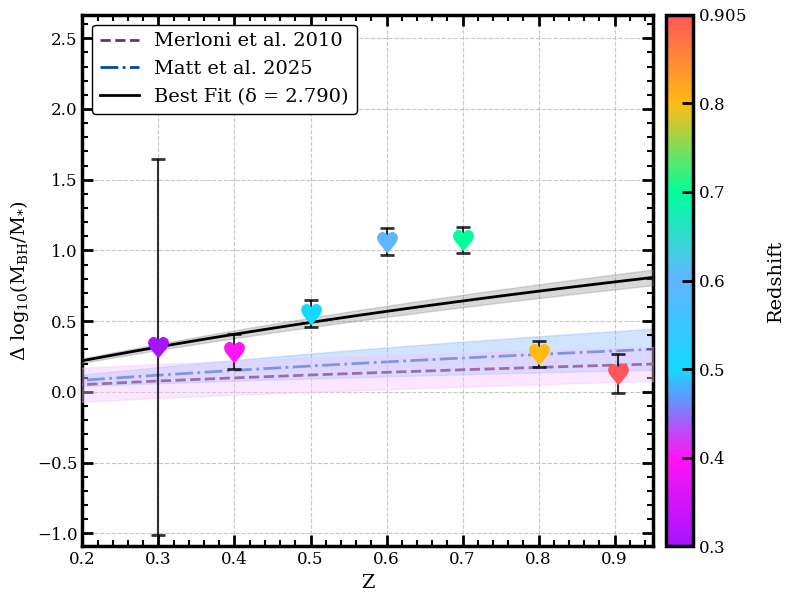

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.cm as cm

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     0.3,
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035,
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035),
    
    ('035_045',
     0.4,
     Delta_BH_Stellar_Broad_AGN_Only_035_045,
     Delta_BH_Stellar_Broad_AGN_Only_SD_035_045),
    
    ('045_055', 
     0.5,
     Delta_BH_Stellar_Broad_AGN_Only_045_055,
     Delta_BH_Stellar_Broad_AGN_Only_SD_045_055),
    
    ('055_065',
     0.6,
     Delta_BH_Stellar_Broad_AGN_Only_055_065,
     Delta_BH_Stellar_Broad_AGN_Only_SD_055_065),
    
    ('065_075', 
     0.7,
     Delta_BH_Stellar_Broad_AGN_Only_065_075,
     Delta_BH_Stellar_Broad_AGN_Only_SD_065_075),
    
    ('075_085', 
     0.8,
     Delta_BH_Stellar_Broad_AGN_Only_075_085,
     Delta_BH_Stellar_Broad_AGN_Only_SD_075_085),
    
    ('085_096', 
     0.905,
     Delta_BH_Stellar_Broad_AGN_Only_085_096,
     Delta_BH_Stellar_Broad_AGN_Only_SD_085_096)
]

x_fit = np.linspace(0.1, 1.0, 100)

# Define power law function
def delta_Z_fit(x, delta):
    return delta * np.log10(1 + x)

# Extract data for fitting
x_data = np.array([dataset[1] for dataset in datasets])
y_data = np.array([dataset[2] for dataset in datasets])
y_errors = np.array([dataset[3] for dataset in datasets])

# Print data for debugging
print("X data:", x_data)
print("Y data:", y_data)
print("Y errors:", y_errors)

# Perform fitting with better error handling and initial guess
try:
    initial_guess = [0.5]
    popt, pcov = curve_fit(
        delta_Z_fit, 
        x_data, 
        y_data, 
        sigma=y_errors, 
        absolute_sigma=True,
        p0=initial_guess,
        maxfev=5000
    )
    
    delta_fit = popt[0]
    delta_err = np.sqrt(np.diag(pcov))[0]
    fit_successful = True
    
    print(f"Fit successful! Delta = {delta_fit:.3f} ± {delta_err:.3f}")
    
except Exception as e:
    fit_successful = False
    print(f"Fit failed with error: {e}")

# Plot Merloni et al. 2010 reference line
z_ref = np.array([0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905, 1.0])
merloni_line = 0.68 * np.log10(1 + z_ref)

ax.plot(z_ref, merloni_line, linewidth=2, linestyle="--", color="#5E386A", label="Merloni et al. 2010", zorder=5) 
ax.fill_between(z_ref, 
                merloni_line - 0.12, 
                merloni_line + 0.12, 
                color="#F3C5FF", alpha=0.4, zorder=5)

# ADD MATT ET AL. 2025 RELATION
# Parameters from Matt et al. 2025
alpha0 = 8.69
beta0 = 1.17
alpha_z = 1.04
alpha_z_err = 0.5

# Calculate Matt et al. 2025 relation
# M_BH = alpha0 * (1+z)^alpha_z * (M_bulge/10^11 M_sun)^beta0
# Converting to delta log10(M_BH/M_*) form
# Assuming M_bulge ≈ M_* and using a reference point at z=0

def matt_relation(z, alpha_z_val):
    """Calculate the Matt et al. 2025 relation in delta form"""
    # Reference at z=0
    ref_term = alpha0 * (1.0)**alpha_z_val
    # Evolution term
    evol_term = alpha0 * (1 + z)**alpha_z_val
    # Delta in log space
    return np.log10(evol_term) - np.log10(ref_term)

z_matt = np.linspace(0.0, 1.0, 100)
matt_line = matt_relation(z_matt, alpha_z)
matt_upper = matt_relation(z_matt, alpha_z + alpha_z_err)
matt_lower = matt_relation(z_matt, alpha_z - alpha_z_err)

ax.plot(z_matt, matt_line, linewidth=2, color="#0047AB", 
        label="Matt et al. 2025", linestyle='-.', zorder=-10)
ax.fill_between(z_matt, matt_lower, matt_upper, 
                color="#8ABBFF", alpha=0.4, zorder=-10)

# Plot fitted curve if successful
if fit_successful:
    y_fit = delta_Z_fit(x_fit, delta_fit)
    y_fit_upper = delta_Z_fit(x_fit, delta_fit + delta_err)
    y_fit_lower = delta_Z_fit(x_fit, delta_fit - delta_err)
    
    ax.plot(x_fit, y_fit, color='black', linewidth=2, 
            label=f'Best Fit (δ = {delta_fit:.3f})', zorder=30)
    ax.fill_between(x_fit, y_fit_lower, y_fit_upper, 
                   color='gray', alpha=0.3, zorder=25)

# Plot each dataset
for i, (key, x_data_point, y_data_point, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data_point, y_data_point,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10000)

    # Plot error bars
    ax.errorbar(x_data_point, y_data_point,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=100)

# Configure axes labels and title
ax.set_xlabel(r"Z", fontsize=14, color="black")
ax.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Create legend
legend1 = ax.legend(loc='upper left', fontsize=14, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0)

# Configure grid
ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.5)

# Set x-axis limits
ax.set_xlim(0.2, 0.95)
#ax.set_ylim(-0.43, 0.5)

# Adjust layout
plt.tight_layout(pad=0.5)


fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Delta_BH_Stella_Z.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')


# Show the figure
plt.show(block=False)


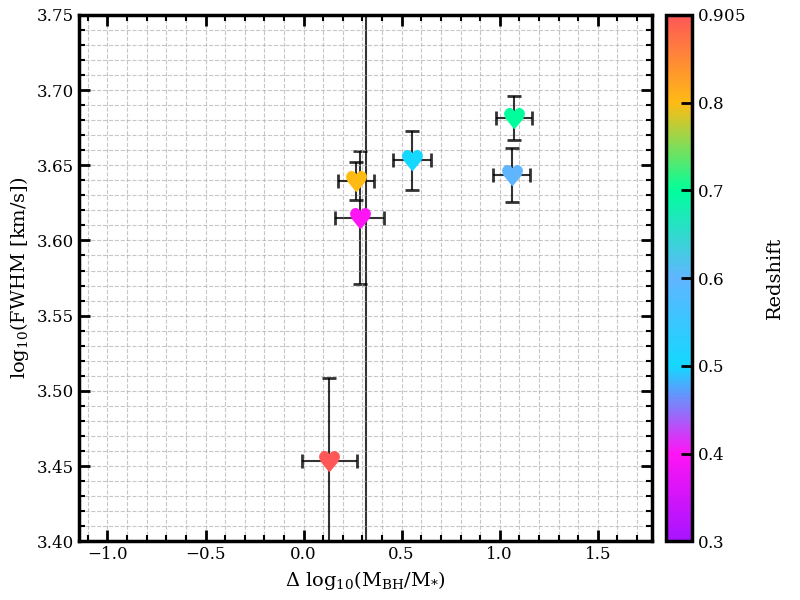

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Broad Component)
datasets = [
    ('025_035', 
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log(10))
     ),
    ('035_045', 
     Delta_BH_Stellar_Broad_AGN_Only_035_045,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     Delta_BH_Stellar_Broad_AGN_Only_SD_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log(10))
     ),
    ('045_055', 
     Delta_BH_Stellar_Broad_AGN_Only_045_055,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     Delta_BH_Stellar_Broad_AGN_Only_SD_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log(10))
     ),
    ('055_065', 
     Delta_BH_Stellar_Broad_AGN_Only_055_065,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     Delta_BH_Stellar_Broad_AGN_Only_SD_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log(10))
     ),
    ('065_075', 
     Delta_BH_Stellar_Broad_AGN_Only_065_075,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     Delta_BH_Stellar_Broad_AGN_Only_SD_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log(10))
     ),
    ('075_085', 
     Delta_BH_Stellar_Broad_AGN_Only_075_085,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     Delta_BH_Stellar_Broad_AGN_Only_SD_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log(10))
     ),
    ('085_096', 
     Delta_BH_Stellar_Broad_AGN_Only_085_096,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     Delta_BH_Stellar_Broad_AGN_Only_SD_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log(10))
     )
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(3.4, 3.75)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


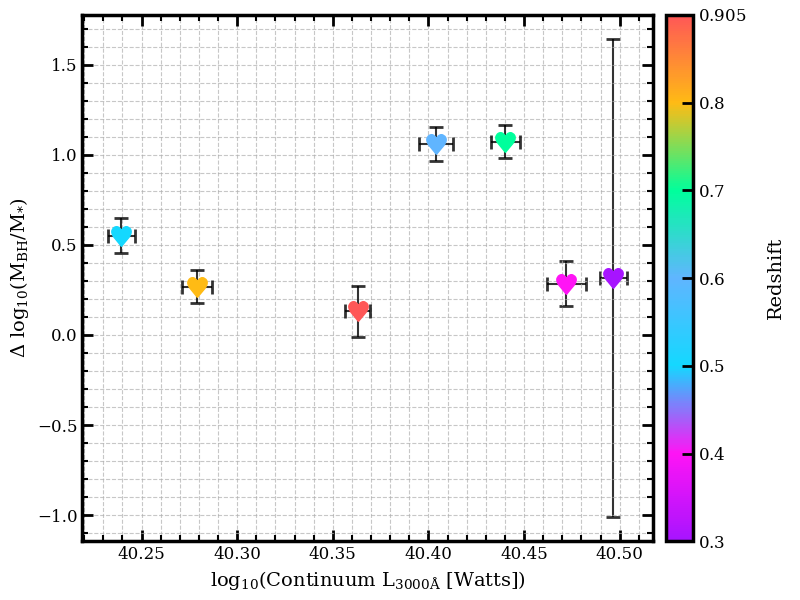

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Narrow Component)
datasets = [
    ('025_035', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_025_035),
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035,
     Luminosities_AGN_Only_Binned_Data_Mean_SD_025_035 / ( Luminosities_AGN_Only_Binned_Data_Mean_025_035 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035),
    ('035_045', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_035_045),
     Delta_BH_Stellar_Broad_AGN_Only_035_045,
     Luminosities_AGN_Only_Binned_Data_Mean_SD_035_045 / ( Luminosities_AGN_Only_Binned_Data_Mean_035_045 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_035_045),
    ('045_055', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_045_055),
     Delta_BH_Stellar_Broad_AGN_Only_045_055,
     Luminosities_AGN_Only_Binned_Data_Mean_SD_045_055 / ( Luminosities_AGN_Only_Binned_Data_Mean_045_055 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_045_055),
    ('055_065', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_055_065),
     Delta_BH_Stellar_Broad_AGN_Only_055_065,
     Luminosities_AGN_Only_Binned_Data_Mean_SD_055_065 / ( Luminosities_AGN_Only_Binned_Data_Mean_055_065 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_055_065),
    ('065_075', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_065_075),
     Delta_BH_Stellar_Broad_AGN_Only_065_075,
     Luminosities_AGN_Only_Binned_Data_Mean_SD_065_075 / ( Luminosities_AGN_Only_Binned_Data_Mean_065_075 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_065_075),
    ('075_085', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_075_085),
     Delta_BH_Stellar_Broad_AGN_Only_075_085,
     Luminosities_AGN_Only_Binned_Data_Mean_SD_075_085 / ( Luminosities_AGN_Only_Binned_Data_Mean_075_085 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_075_085),
    ('085_096', 
     np.log10(Luminosities_AGN_Only_Binned_Data_Mean_085_096),
     Delta_BH_Stellar_Broad_AGN_Only_085_096,
     Luminosities_AGN_Only_Binned_Data_Mean_SD_085_096 / ( Luminosities_AGN_Only_Binned_Data_Mean_085_096 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
ax.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Narrow - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_xlim(40.75, 40.92)
#ax.set_ylim(-0.1, 0.7)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


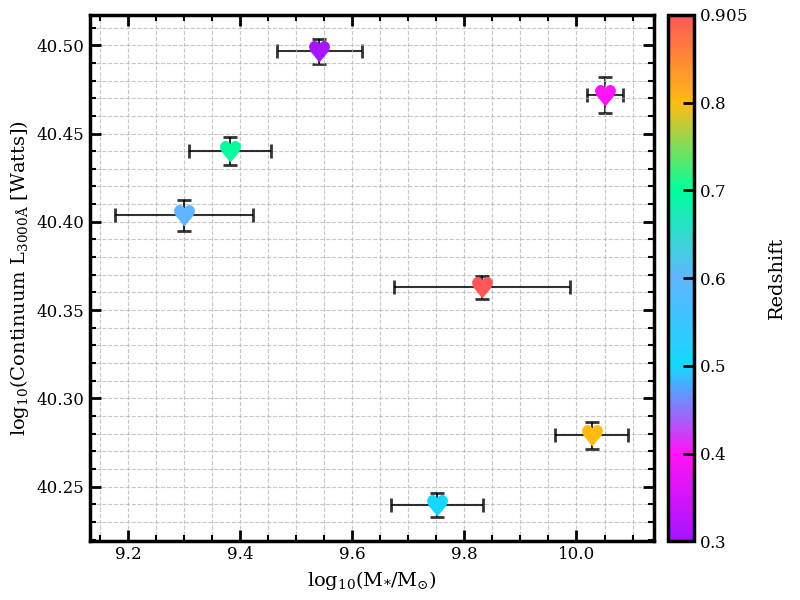

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]



# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    Stellar_Mass_Average_025_035,
    np.log10(Luminosities_AGN_Only_Binned_Data_Mean_025_035),
    Stellar_Mass_SD_025_035,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_025_035 / (Luminosities_AGN_Only_Binned_Data_Mean_025_035 * np.log(10))), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    Stellar_Mass_Average_035_045,
    np.log10(Luminosities_AGN_Only_Binned_Data_Mean_035_045),
    Stellar_Mass_SD_035_045,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_035_045 / ( Luminosities_AGN_Only_Binned_Data_Mean_035_045 * np.log(10))),
    ('045_055', 
    Stellar_Mass_Average_045_055,
    np.log10(Luminosities_AGN_Only_Binned_Data_Mean_045_055),
    Stellar_Mass_SD_045_055,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_045_055 / ( Luminosities_AGN_Only_Binned_Data_Mean_045_055 * np.log(10))),
    ('055_065', 
    Stellar_Mass_Average_055_065,
    np.log10(Luminosities_AGN_Only_Binned_Data_Mean_055_065),
    Stellar_Mass_SD_055_065,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_055_065 / ( Luminosities_AGN_Only_Binned_Data_Mean_055_065 * np.log(10))),
    ('065_075', 
    Stellar_Mass_Average_065_075,
    np.log10(Luminosities_AGN_Only_Binned_Data_Mean_065_075),
    Stellar_Mass_SD_065_075,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_065_075 / ( Luminosities_AGN_Only_Binned_Data_Mean_065_075 * np.log(10))),
    ('075_085', 
    Stellar_Mass_Average_075_085,
    np.log10(Luminosities_AGN_Only_Binned_Data_Mean_075_085),
    Stellar_Mass_SD_075_085,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_075_085 / ( Luminosities_AGN_Only_Binned_Data_Mean_075_085 * np.log(10))),
    ('085_096', 
    Stellar_Mass_Average_085_096,
    np.log10(Luminosities_AGN_Only_Binned_Data_Mean_085_096),
    Stellar_Mass_SD_085_096,
    Luminosities_AGN_Only_Binned_Data_Mean_SD_085_096 / ( Luminosities_AGN_Only_Binned_Data_Mean_085_096 * np.log(10)))
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(40.75, 40.93)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


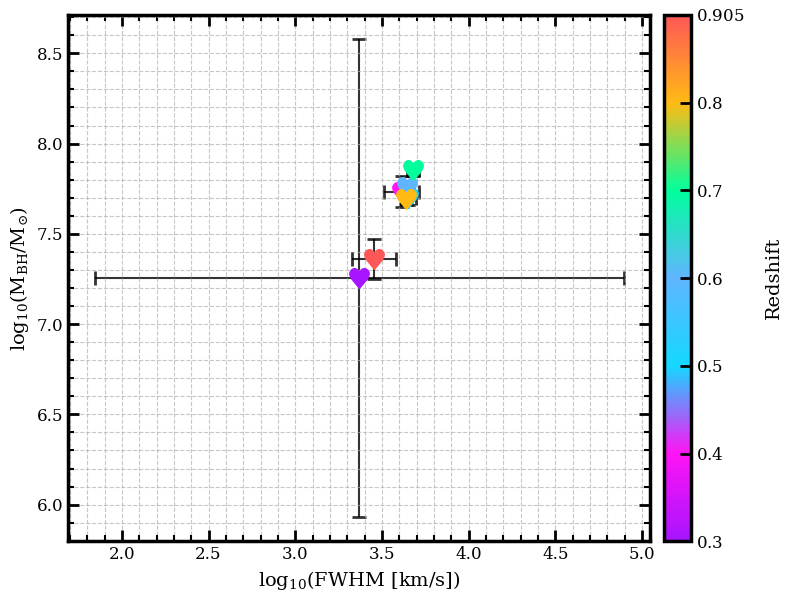

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035*np.log(10))), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045*np.log(10))),
    ('045_055', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055*np.log(10))),
    ('055_065', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065*np.log(10))),
    ('065_075', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075*np.log(10))),
    ('075_085', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085*np.log(10))),
    ('085_096', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096*np.log(10)))
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


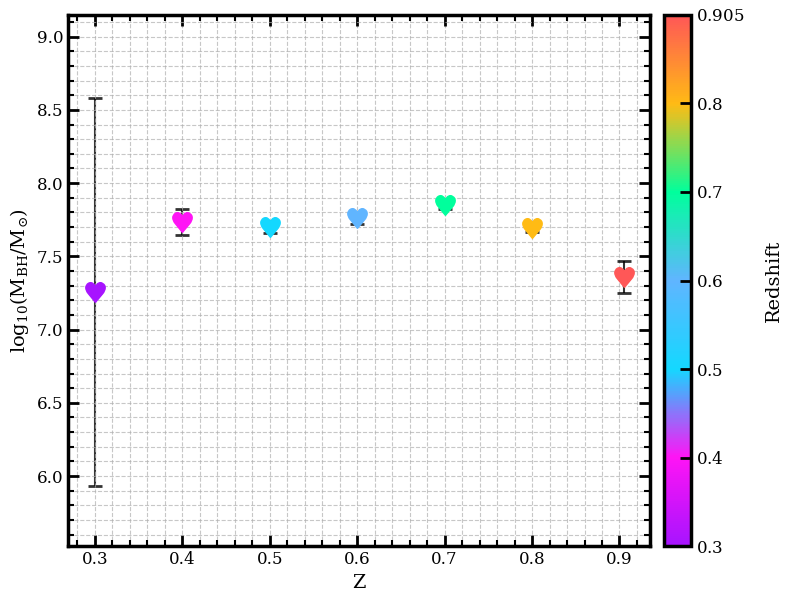

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    0.3,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035*np.log(10))
    ), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    0.4,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045*np.log(10))
    ),
    ('045_055', 
    0.5,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055*np.log(10))
    ),
    ('055_065', 
    0.6,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065*np.log(10))
    ),
    ('065_075', 
    0.7,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075*np.log(10))
    ),
    ('075_085', 
    0.8,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085*np.log(10))
    ),
    ('085_096', 
    0.905,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096*np.log(10))
    )
]



# Plot each dataset
for i, (key, x_data, y_data, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Z", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


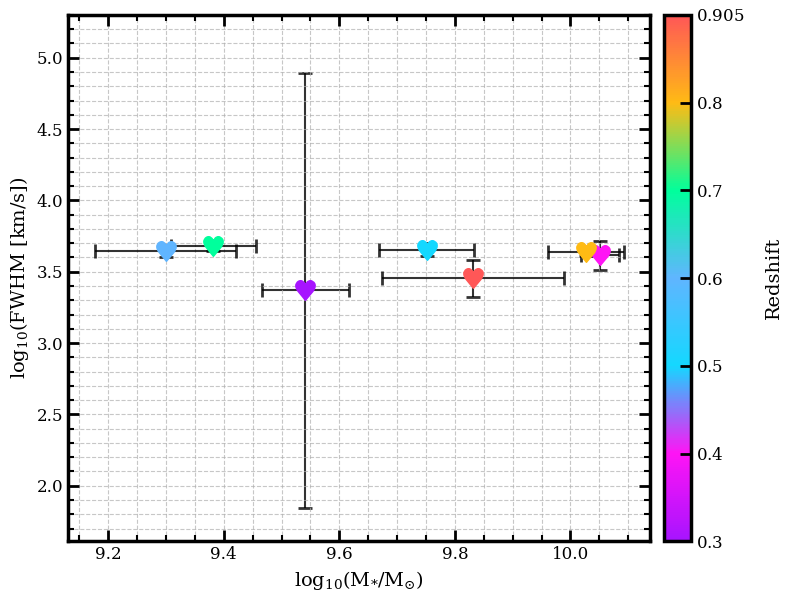

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]


# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    Stellar_Mass_Average_025_035,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
    Stellar_Mass_SD_025_035,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10))), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    Stellar_Mass_Average_035_045,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
    Stellar_Mass_SD_035_045,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10))),
    ('045_055', 
    Stellar_Mass_Average_045_055,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
    Stellar_Mass_SD_045_055,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10))),
    ('055_065', 
    Stellar_Mass_Average_055_065,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
    Stellar_Mass_SD_055_065,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10))),
    ('065_075', 
    Stellar_Mass_Average_065_075,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
    Stellar_Mass_SD_065_075,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10))),
    ('075_085', 
    Stellar_Mass_Average_075_085,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
    Stellar_Mass_SD_075_085,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10))),
    ('085_096', 
    Stellar_Mass_Average_085_096,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
    Stellar_Mass_SD_085_096,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)))
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


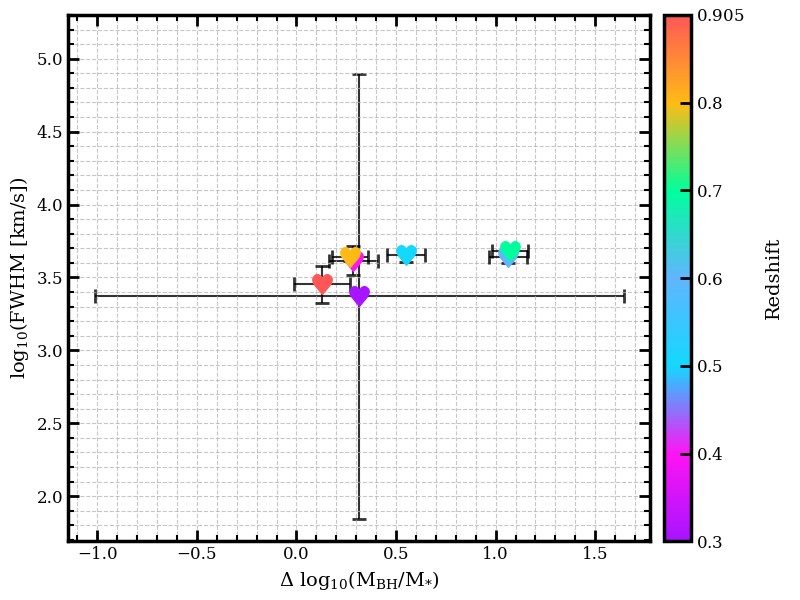

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Narrow Component)
datasets = [
    ('025_035', 
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10))),
    ('035_045', 
     Delta_BH_Stellar_Broad_AGN_Only_035_045,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     Delta_BH_Stellar_Broad_AGN_Only_SD_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10))),
    ('045_055', 
     Delta_BH_Stellar_Broad_AGN_Only_045_055,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     Delta_BH_Stellar_Broad_AGN_Only_SD_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10))),
    ('055_065', 
     Delta_BH_Stellar_Broad_AGN_Only_055_065,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     Delta_BH_Stellar_Broad_AGN_Only_SD_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10))),
    ('065_075', 
     Delta_BH_Stellar_Broad_AGN_Only_065_075,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     Delta_BH_Stellar_Broad_AGN_Only_SD_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10))),
    ('075_085', 
     Delta_BH_Stellar_Broad_AGN_Only_075_085,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     Delta_BH_Stellar_Broad_AGN_Only_SD_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10))),
    ('085_096', 
     Delta_BH_Stellar_Broad_AGN_Only_085_096,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     Delta_BH_Stellar_Broad_AGN_Only_SD_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)))
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Narrow - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

# Save and show the figure
plt.show(block=False)



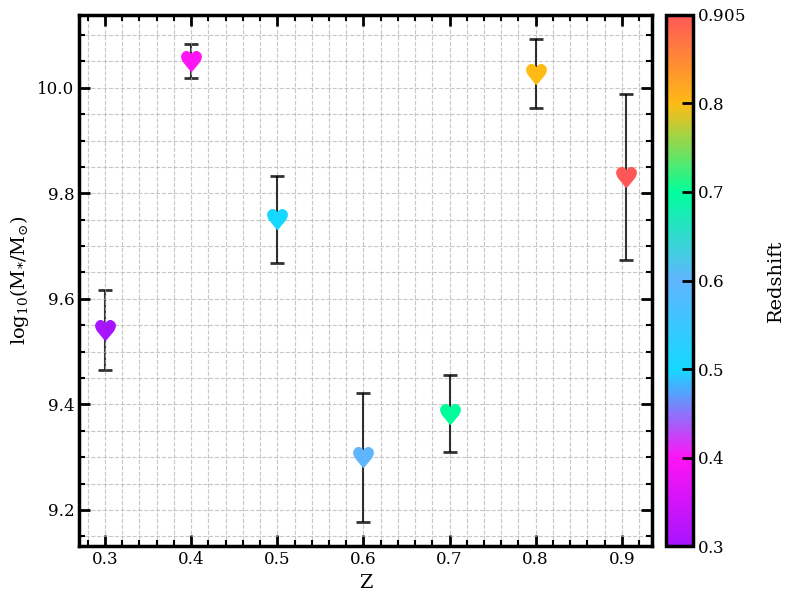

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]


# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    0.3,
    Stellar_Mass_Average_025_035,
    Stellar_Mass_SD_025_035), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    0.4,
    Stellar_Mass_Average_035_045,
    Stellar_Mass_SD_035_045),
    ('045_055', 
    0.5,
    Stellar_Mass_Average_045_055,
    Stellar_Mass_SD_045_055),
    ('055_065', 
    0.6,
    Stellar_Mass_Average_055_065,
    Stellar_Mass_SD_055_065),
    ('065_075', 
    0.7,
    Stellar_Mass_Average_065_075,
    Stellar_Mass_SD_065_075),
    ('075_085', 
    0.8,
    Stellar_Mass_Average_075_085,
    Stellar_Mass_SD_075_085),
    ('085_096', 
    0.905,
    Stellar_Mass_Average_085_096,
    Stellar_Mass_SD_085_096)
]



# Plot each dataset
for i, (key, x_data, y_data, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
        
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title 
ax.set_xlabel(r"Z", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


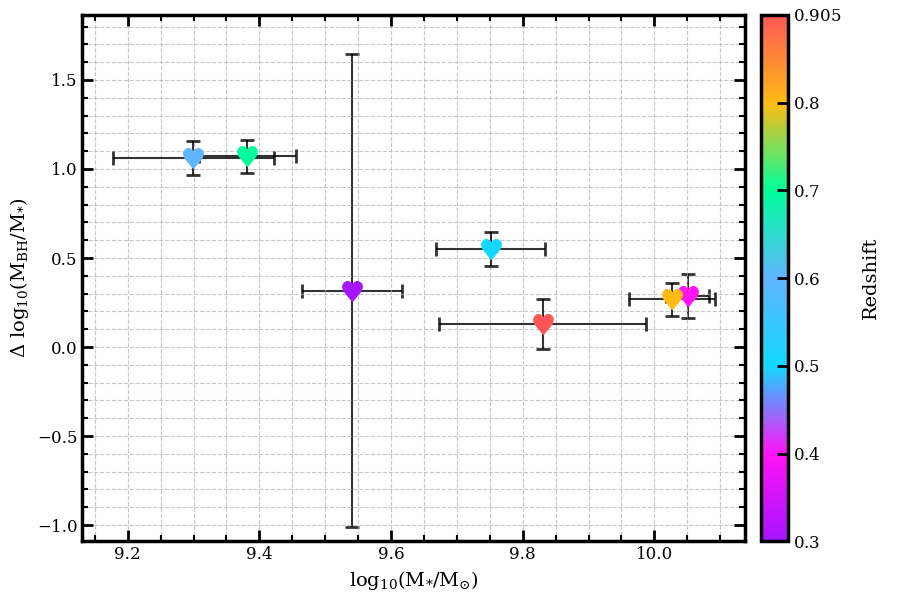

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(9, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    Stellar_Mass_Average_025_035,
    Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035,
    Stellar_Mass_SD_025_035,
    Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    Stellar_Mass_Average_035_045,
    Delta_BH_Stellar_Broad_AGN_Only_035_045,
    Stellar_Mass_SD_035_045,
    Delta_BH_Stellar_Broad_AGN_Only_SD_035_045),
    ('045_055', 
    Stellar_Mass_Average_045_055,
    Delta_BH_Stellar_Broad_AGN_Only_045_055,
    Stellar_Mass_SD_045_055,
    Delta_BH_Stellar_Broad_AGN_Only_SD_045_055),
    ('055_065', 
    Stellar_Mass_Average_055_065,
    Delta_BH_Stellar_Broad_AGN_Only_055_065,
    Stellar_Mass_SD_055_065,
    Delta_BH_Stellar_Broad_AGN_Only_SD_055_065),
    ('065_075', 
    Stellar_Mass_Average_065_075,
    Delta_BH_Stellar_Broad_AGN_Only_065_075,
    Stellar_Mass_SD_065_075,
    Delta_BH_Stellar_Broad_AGN_Only_SD_065_075),
    ('075_085', 
    Stellar_Mass_Average_075_085,
    Delta_BH_Stellar_Broad_AGN_Only_075_085,
    Stellar_Mass_SD_075_085,
    Delta_BH_Stellar_Broad_AGN_Only_SD_075_085),
    ('085_096', 
    Stellar_Mass_Average_085_096,
    Delta_BH_Stellar_Broad_AGN_Only_085_096,
    Stellar_Mass_SD_085_096,
    Delta_BH_Stellar_Broad_AGN_Only_SD_085_096)
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, yerr) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr = yerr,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

## Configure legend with MNRAS style
#legend = ax.legend(
#    loc='lower left',
#    fontsize=12,
#    frameon=True,
#    fancybox=True,
#    shadow=True,
#    borderpad=0.8,
#    handletextpad=0.6,
#    columnspacing=1.0,
#    handlelength=1.0,
#    labelspacing=1.0,
#    numpoints=1
#)
#legend.get_frame().set_linewidth(1.5)
#legend.get_frame().set_edgecolor('black')

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


## <font color='#00879E' size=5 >Adding in other data - from the Luminosity Corrected data - Uniform Narrow Sigma - FeII Removed </font>


In [26]:
##https://iopscience.iop.org/article/10.1088/0004-637X/813/2/82/pdf

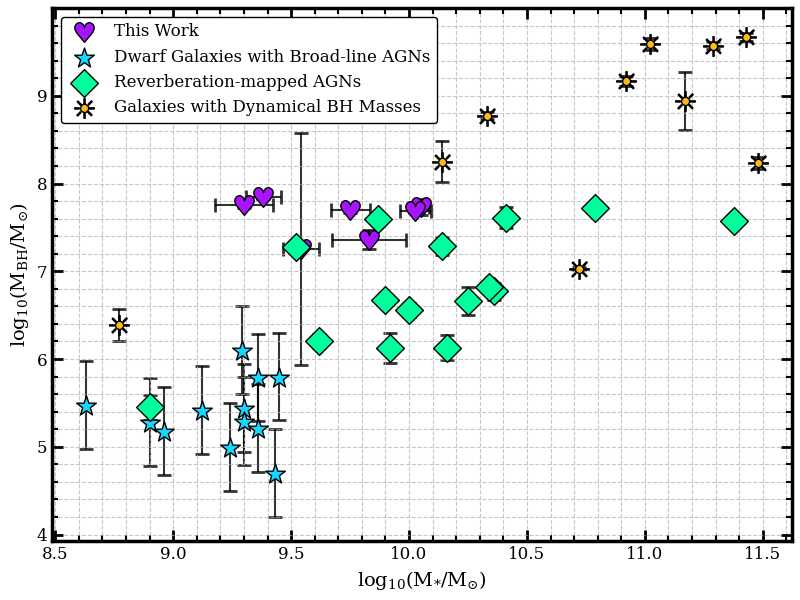

In [27]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23}, 

]

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme from the original heart markers (keeping the same vibrant colors)
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"] #Purple (deep/cool), Pink, Teal, Blue, Green, Orange, Red (warm)


# Single color for heart markers (choose one from the original palette)
heart_color = "#a714ff"  # Using the teal color for all hearts

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    Stellar_Mass_Average_025_035,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035),
    Stellar_Mass_SD_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035*np.log(10))),
    ('035_045', 
    Stellar_Mass_Average_035_045,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045),
    Stellar_Mass_SD_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045*np.log(10))),
    ('045_055', 
    Stellar_Mass_Average_045_055,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055),
    Stellar_Mass_SD_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055*np.log(10))),
    ('055_065', 
    Stellar_Mass_Average_055_065,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065),
    Stellar_Mass_SD_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065*np.log(10))),
    ('065_075', 
    Stellar_Mass_Average_065_075,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075),
    Stellar_Mass_SD_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075*np.log(10))),
    ('075_085', 
    Stellar_Mass_Average_075_085,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085),
    Stellar_Mass_SD_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085*np.log(10))),
    ('085_096', 
    Stellar_Mass_Average_085_096,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096),
    Stellar_Mass_SD_085_096,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096*np.log(10)))
]

# Plot each dataset with the same heart marker color - single legend entry
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers (all same color)
    ax.scatter(x_data, y_data,
              color=heart_color,
              edgecolor="black",
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label='This Work' if i == 0 else '')
    
    # Plot error bars (all black)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Add galaxy data to the plot with fun shaped markers
# Extract data for plotting
dwarf_x = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y_err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

reverberation_x = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]
reverberation_y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
reverberation_y_err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

dynamical_x = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y_err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

# Plot dwarf galaxies with broad-line AGNs using star marker
ax.scatter(dwarf_x, dwarf_y,
          color=dataset_colors[2],  # Bright teal
          s=200,
          marker=u"$\u2605$",  # Star marker
          alpha=1.0,
          edgecolors='black',
          linewidth=1,
          zorder=20,
          label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars (all black)
ax.errorbar(dwarf_x, dwarf_y,
           yerr=dwarf_y_err,
           linestyle='',
           ecolor='black',
           capsize=5,
           capthick=2,
           elinewidth=1.5,
           alpha=0.8,
           zorder=0)

# Plot reverberation-mapped AGNs using diamond marker
ax.scatter(reverberation_x, reverberation_y,
          color=dataset_colors[4],  # Green
          s=200,
          marker="D",  # Diamond suit marker
          alpha=1.0,
          edgecolors='black',
          linewidth=1,
          zorder=20,
          label='Reverberation-mapped AGNs')

# Plot error bars (all black)
ax.errorbar(reverberation_x, reverberation_y,
           yerr=reverberation_y_err,
           linestyle='',
           ecolor='black',
           capsize=5,
           capthick=2,
           elinewidth=1.5,
           alpha=0.8,
           zorder=0)

# Plot galaxies with dynamical BH masses using sun marker
ax.scatter(dynamical_x, dynamical_y,
          color=dataset_colors[5],  # Orange
          s=200,
          marker=u"$\u2600$",  # Sun marker
          alpha=1.0,
          edgecolors='black',
          linewidth=1,
          zorder=20,
          label='Galaxies with Dynamical BH Masses')

# Plot error bars (all black)
ax.errorbar(dynamical_x, dynamical_y,
           yerr=dynamical_y_err,
           linestyle='',
           ecolor='black',
           capsize=5,
           capthick=2,
           elinewidth=1.5,
           alpha=0.8,
           zorder=0)

# Configure axes labels
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

# Create legend
legend1 = ax.legend(loc='upper left', fontsize=12, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Modified_Plot.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Modified_Plot.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)

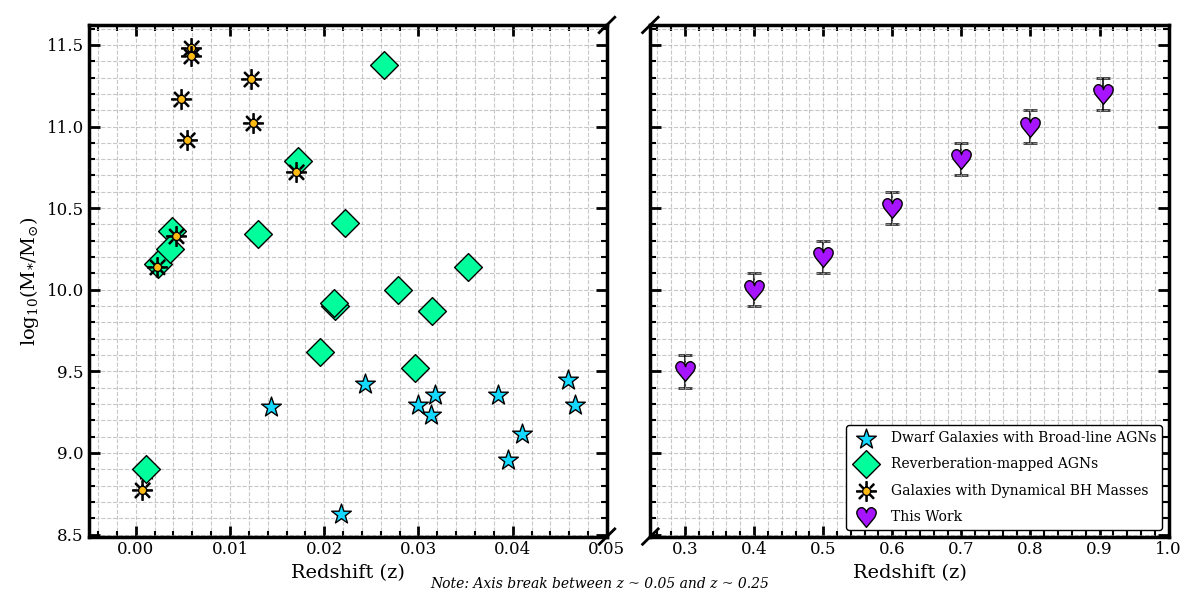

In [28]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]

# Your data with redshift and stellar mass values
our_data = [
    {"name": "025_035", "redshift": 0.3, "logMs": 9.5, "logMs_uncertainty": 0.1},  # Placeholder stellar mass
    {"name": "035_045", "redshift": 0.4, "logMs": 10.0, "logMs_uncertainty": 0.1},
    {"name": "045_055", "redshift": 0.5, "logMs": 10.2, "logMs_uncertainty": 0.1},
    {"name": "055_065", "redshift": 0.6, "logMs": 10.5, "logMs_uncertainty": 0.1},
    {"name": "065_075", "redshift": 0.7, "logMs": 10.8, "logMs_uncertainty": 0.1},
    {"name": "075_085", "redshift": 0.8, "logMs": 11.0, "logMs_uncertainty": 0.1},
    {"name": "085_096", "redshift": 0.905, "logMs": 11.2, "logMs_uncertainty": 0.1}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Extract data for plotting
our_x = [data["redshift"] for data in our_data]
our_y = [data["logMs"] for data in our_data]
our_y_err = [data["logMs_uncertainty"] for data in our_data]

dwarf_x = [galaxy["redshift"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

reverberation_x = [galaxy["redshift"] for galaxy in reverberationMappedAGNs]
reverberation_y = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]

dynamical_x = [galaxy["redshift"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Stellar_Mass_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Stellar_Mass_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


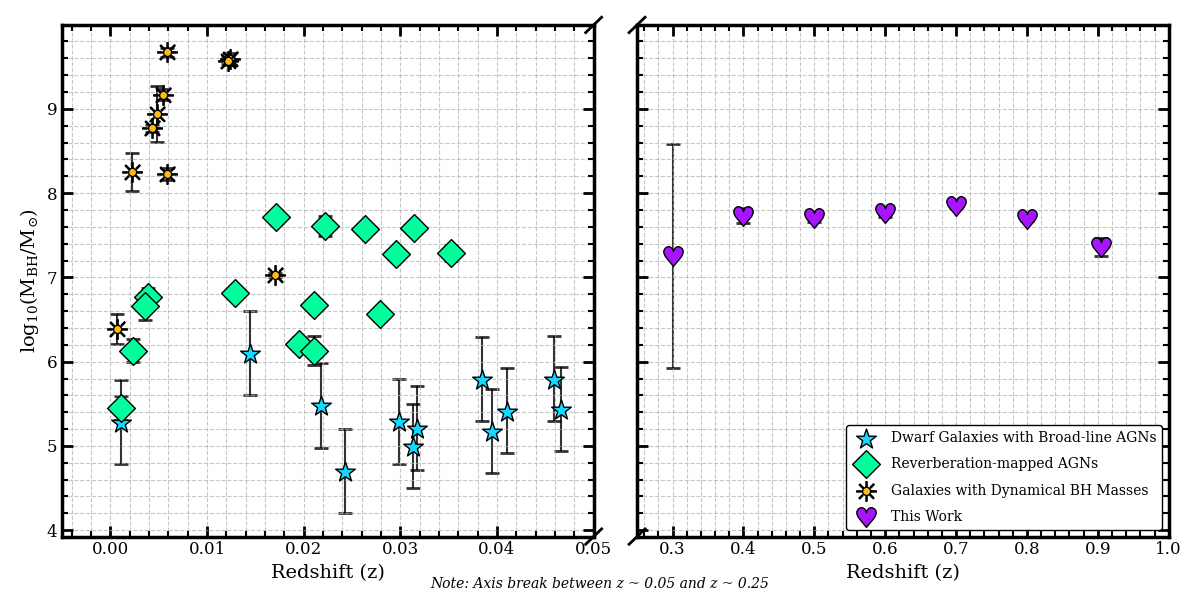

In [29]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]

# Your data with redshift and black hole mass values
our_data = [
    {"name": "025_035", "redshift": 0.3, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035*np.log(10))},  # Placeholder BH mass
    {"name": "035_045", "redshift": 0.4, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045*np.log(10))},
    {"name": "045_055", "redshift": 0.5, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055*np.log(10))},
    {"name": "055_065", "redshift": 0.6, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065*np.log(10))},
    {"name": "065_075", "redshift": 0.7, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075*np.log(10))},
    {"name": "075_085", "redshift": 0.8, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085*np.log(10))},
    {"name": "085_096", "redshift": 0.905, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096*np.log(10))}
]


# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Extract data for plotting
our_x = [data["redshift"] for data in our_data]
our_y = [data["logMBH"] for data in our_data]
our_y_err = [data["logMBH_uncertainty"] for data in our_data]

dwarf_x = [galaxy["redshift"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y_err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

reverberation_x = [galaxy["redshift"] for galaxy in reverberationMappedAGNs]
reverberation_y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
reverberation_y_err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

dynamical_x = [galaxy["redshift"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y_err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Stellar_Mass_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Stellar_Mass_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


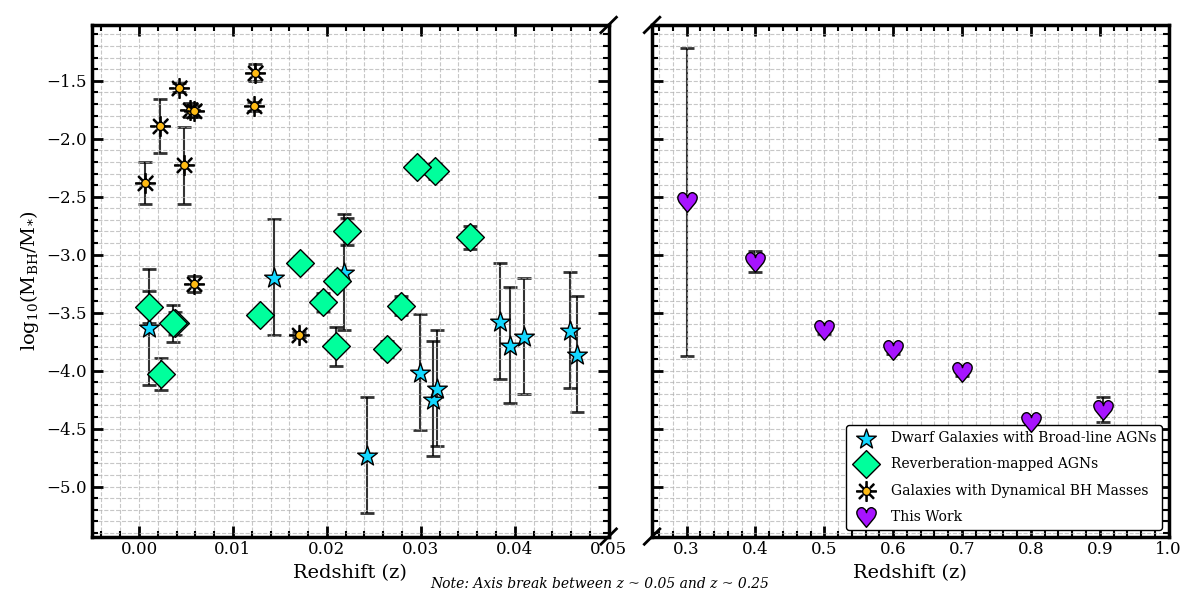

In [30]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]

# Your data with redshift and black hole mass values
our_data = [
    {"name": "025_035", "redshift": 0.3, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035*np.log(10)), "logMs": 9.8},
    {"name": "035_045", "redshift": 0.4, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045*np.log(10)), "logMs": 10.1},
    {"name": "045_055", "redshift": 0.5, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055*np.log(10)), "logMs": 10.3},
    {"name": "055_065", "redshift": 0.6, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065*np.log(10)), "logMs": 10.5},
    {"name": "065_075", "redshift": 0.7, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075*np.log(10)), "logMs": 10.7},
    {"name": "075_085", "redshift": 0.8, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085*np.log(10)), "logMs": 10.9},
    {"name": "085_096", "redshift": 0.905, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096*np.log(10)), "logMs": 11.1}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Calculate log(MBH/Ms) for all datasets
def calculate_mass_ratio(data_list):
    x_vals = []
    y_vals = []
    y_err_vals = []
    
    for data in data_list:
        x_vals.append(data["redshift"])
        # Calculate log(MBH/Ms) = log(MBH) - log(Ms)
        mass_ratio = data["logMBH"] - data["logMs"]
        y_vals.append(mass_ratio)
        # Error propagation: since we're subtracting logs, uncertainty remains the same for MBH
        y_err_vals.append(data["logMBH_uncertainty"])
    
    return x_vals, y_vals, y_err_vals

# Extract data for plotting
our_x, our_y, our_y_err = calculate_mass_ratio(our_data)
dwarf_x, dwarf_y, dwarf_y_err = calculate_mass_ratio(dwarfGalaxiesWithBroadlineAGNs)
reverberation_x, reverberation_y, reverberation_y_err = calculate_mass_ratio(reverberationMappedAGNs)
dynamical_x, dynamical_y, dynamical_y_err = calculate_mass_ratio(galaxiesWithDynamicalBHMasses)

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


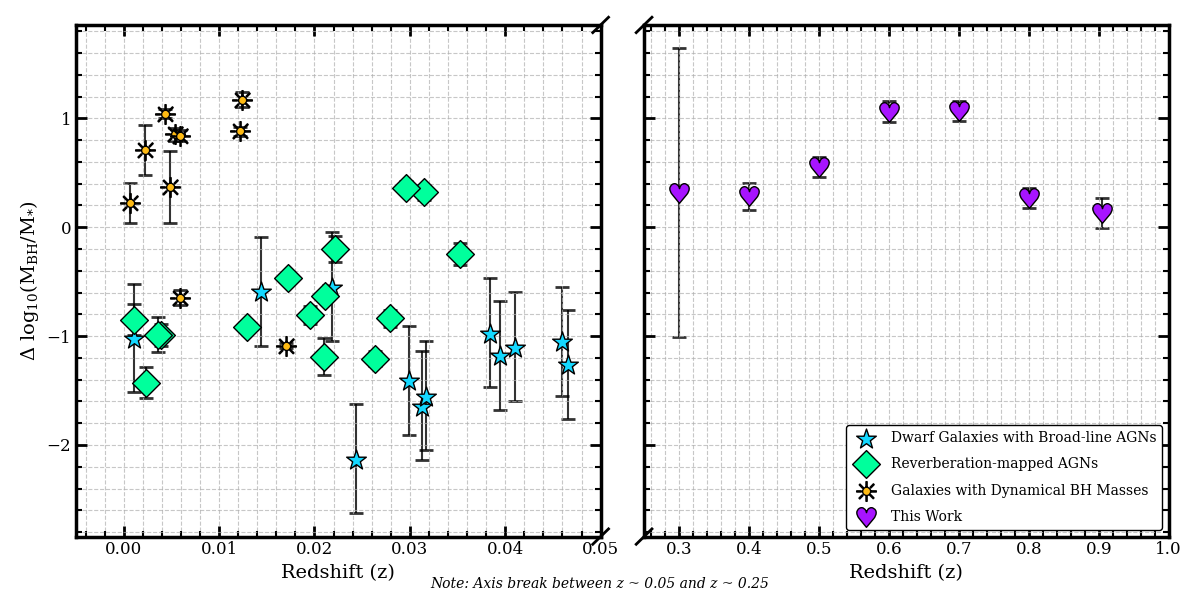

In [31]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]

# Your data using pre-calculated delta values
our_data = [
    {"name": "025_035", "redshift": 0.3, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035},
    {"name": "035_045", "redshift": 0.4, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_035_045, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_035_045},
    {"name": "045_055", "redshift": 0.5, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_045_055, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_045_055},
    {"name": "055_065", "redshift": 0.6, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_055_065, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_055_065},
    {"name": "065_075", "redshift": 0.7, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_065_075, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_065_075},
    {"name": "075_085", "redshift": 0.8, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_075_085, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_075_085},
    {"name": "085_096", "redshift": 0.905, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_085_096, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_085_096}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Calculate Delta log(MBH/Ms) for all datasets
def calculate_delta_mass_ratio(data_list):
    x_vals = []
    y_vals = []
    y_err_vals = []
    
    # Reference value: log10(0.0025)
    log_reference = np.log10(0.0025)
    
    for data in data_list:
        x_vals.append(data["redshift"])
        # Calculate Delta log(MBH/Ms) = log(MBH/Ms) - log(0.0025)
        # This is equivalent to: log(MBH) - log(Ms) - log(0.0025)
        mass_ratio = data["logMBH"] - data["logMs"]
        delta_mass_ratio = mass_ratio - log_reference
        y_vals.append(delta_mass_ratio)
        # Error propagation: since we're subtracting logs, uncertainty remains the same for MBH
        y_err_vals.append(data["logMBH_uncertainty"])
    
    return x_vals, y_vals, y_err_vals

# Extract data for plotting
# For our data, use pre-calculated values directly
our_x = [data["redshift"] for data in our_data]
our_y = [data["delta_value"] for data in our_data]
our_y_err = [data["delta_uncertainty"] for data in our_data]

# For comparison data, calculate delta values
dwarf_x, dwarf_y, dwarf_y_err = calculate_delta_mass_ratio(dwarfGalaxiesWithBroadlineAGNs)
reverberation_x, reverberation_y, reverberation_y_err = calculate_delta_mass_ratio(reverberationMappedAGNs)
dynamical_x, dynamical_y, dynamical_y_err = calculate_delta_mass_ratio(galaxiesWithDynamicalBHMasses)

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)

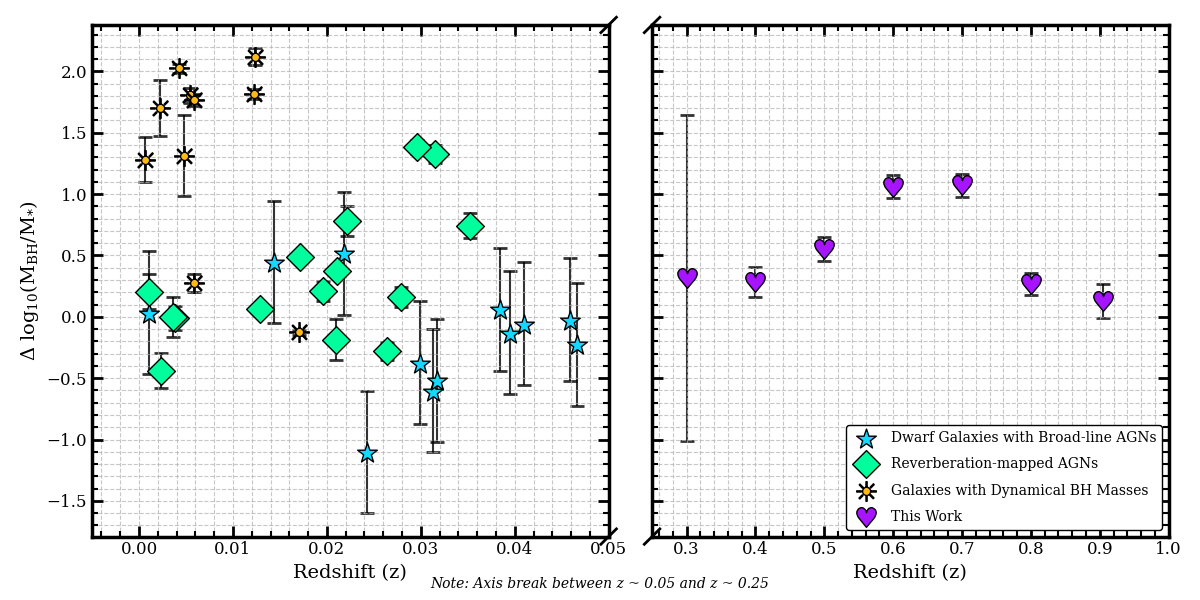

In [32]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]


# Your data using pre-calculated delta values
our_data = [
    {"name": "025_035", "redshift": 0.3, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035},
    {"name": "035_045", "redshift": 0.4, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_035_045, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_035_045},
    {"name": "045_055", "redshift": 0.5, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_045_055, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_045_055},
    {"name": "055_065", "redshift": 0.6, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_055_065, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_055_065},
    {"name": "065_075", "redshift": 0.7, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_065_075, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_065_075},
    {"name": "075_085", "redshift": 0.8, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_075_085, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_075_085},
    {"name": "085_096", "redshift": 0.905, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_085_096, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_085_096}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Calculate Delta log(MBH/Ms) relative to scaling relation
def calculate_delta_mass_ratio(data_list):
    x_vals = []
    y_vals = []
    y_err_vals = []
    
    # Scaling relation parameters
    alpha = 7.45
    beta = 1.05
    
    for data in data_list:
        x_vals.append(data["redshift"])
        
        # Calculate observed log(MBH/Ms)
        observed_mass_ratio = data["logMBH"] - data["logMs"]
        
        # Calculate expected log(MBH) from scaling relation
        # log(MBH/M☉) = α + β * log(Mstellar/10^11 M☉)
        # log(Mstellar/10^11 M☉) = log(Mstellar) - 11 = logMs - 11
        log_stellar_scaled = data["logMs"] - 11.0
        expected_log_MBH = alpha + beta * log_stellar_scaled
        
        # Calculate expected log(MBH/Ms)
        expected_mass_ratio = expected_log_MBH - data["logMs"]
        
        # Calculate delta: observed - expected
        delta_mass_ratio = observed_mass_ratio - expected_mass_ratio
        y_vals.append(delta_mass_ratio)
        
        # Error propagation: uncertainty remains the same for MBH
        y_err_vals.append(data["logMBH_uncertainty"])
    
    return x_vals, y_vals, y_err_vals

# Extract data for plotting
# For our data, use pre-calculated delta values directly
our_x = [data["redshift"] for data in our_data]
our_y = [data["delta_value"] for data in our_data]
our_y_err = [data["delta_uncertainty"] for data in our_data]

# For comparison data, calculate delta values using same reference
dwarf_x, dwarf_y, dwarf_y_err = calculate_delta_mass_ratio(dwarfGalaxiesWithBroadlineAGNs)
reverberation_x, reverberation_y, reverberation_y_err = calculate_delta_mass_ratio(reverberationMappedAGNs)
dynamical_x, dynamical_y, dynamical_y_err = calculate_delta_mass_ratio(galaxiesWithDynamicalBHMasses)

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [33]:
"""
Getting the delta black hole mass over stellar mass and the standard deviation
relative to the scaling relation
"""
import numpy as np

def standard_deviation_delta_BH_Stellar_relation(M_BH, M_BH_SD, M_Stellar, M_Stellar_SD, alpha=7.45, beta=1.05, alpha_SD=0.08, beta_SD=0.11):
    """
    This code finds the standard deviation for the delta black hole stellar mass relation
    relative to the scaling relation: log(MBH/M☉) = α + β * log(Mstellar/10^11 M☉)

    Parameters
    ----------
    M_BH: Black hole mass [NOT Log]
    M_BH_SD: Black hole mass standard deviation

    M_Stellar: Stellar mass [NOT log]
    M_Stellar_SD: Stellar mass standard deviation average [NOT log] 

    alpha: Scaling relation intercept (default: 7.45)
    beta: Scaling relation slope (default: 1.05)
    alpha_SD: Scaling relation intercept error (default: 0.08)
    beta_SD: Scaling relation slope error (default: 0.11)

    Return
    ------
    Delta_BH_Stellar_SD: The standard deviation for the delta black hole stellar mass relation
    """
    
    # Convert to log space
    log_M_BH = np.log10(M_BH)
    log_M_Stellar = np.log10(M_Stellar)
    
    # Calculate scaling relation prediction
    log_stellar_scaled = log_M_Stellar - 11.0  # log(Mstellar/10^11 M☉)
    expected_log_MBH = alpha + beta * log_stellar_scaled
    
    # Partial derivatives for error propagation
    # For observed log(MBH/Ms): d/d(log_MBH) = 1, d/d(log_Ms) = -1
    # For expected: d/d(alpha) = -1, d/d(beta) = -log_stellar_scaled, d/d(log_Ms) = beta
    
    # Error propagation terms
    term_MBH = (1 / (M_BH * np.log(10)) * M_BH_SD)**2  # from M_BH uncertainty
    term_Ms_observed = (-1 / (M_Stellar * np.log(10)) * M_Stellar_SD)**2  # from Ms in observed ratio
    term_Ms_expected = (beta / (M_Stellar * np.log(10)) * M_Stellar_SD)**2  # from Ms in expected ratio
    term_alpha = (-alpha_SD)**2  # from alpha uncertainty
    term_beta = (log_stellar_scaled * beta_SD)**2  # from beta uncertainty
    
    return np.sqrt(term_MBH + term_Ms_observed + term_Ms_expected + term_alpha + term_beta)


def calculate_delta_BH_stellar_relation(BH_Mass, Stellar_Mass_log, alpha=7.45, beta=1.05):
    """
    Calculate delta relative to scaling relation
    
    Parameters
    ----------
    BH_Mass: Black hole mass [NOT log]
    Stellar_Mass_log: log10(Stellar mass)
    alpha: Scaling relation intercept
    beta: Scaling relation slope
    
    Returns
    -------
    Delta value relative to scaling relation
    """
    # Observed log(MBH/Ms)
    observed_ratio = np.log10(BH_Mass) - Stellar_Mass_log
    
    # Expected log(MBH) from scaling relation
    log_stellar_scaled = Stellar_Mass_log - 11.0
    expected_log_MBH = alpha + beta * log_stellar_scaled
    
    # Expected log(MBH/Ms)
    expected_ratio = expected_log_MBH - Stellar_Mass_log
    
    # Delta = observed - expected
    return observed_ratio - expected_ratio


# Getting the delta black hole stellar mass relation (relative to scaling relation)
Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035, 
    Stellar_Mass_Average_025_035)

Delta_BH_Stellar_Broad_AGN_Only_035_045_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045, 
    Stellar_Mass_Average_035_045)

Delta_BH_Stellar_Broad_AGN_Only_045_055_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055, 
    Stellar_Mass_Average_045_055)

Delta_BH_Stellar_Broad_AGN_Only_055_065_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065, 
    Stellar_Mass_Average_055_065)

Delta_BH_Stellar_Broad_AGN_Only_065_075_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075, 
    Stellar_Mass_Average_065_075)

Delta_BH_Stellar_Broad_AGN_Only_075_085_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085, 
    Stellar_Mass_Average_075_085)

Delta_BH_Stellar_Broad_AGN_Only_085_096_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096, 
    Stellar_Mass_Average_085_096)


# Getting the standard deviation for the delta black hole stellar mass relation (relative to scaling relation)
Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035, 
    10**Stellar_Mass_Average_025_035, 
    10**Stellar_Mass_SD_025_035)

Delta_BH_Stellar_Broad_AGN_Only_SD_035_045_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045, 
    10**Stellar_Mass_Average_035_045, 
    10**Stellar_Mass_SD_035_045)

Delta_BH_Stellar_Broad_AGN_Only_SD_045_055_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055, 
    10**Stellar_Mass_Average_045_055, 
    10**Stellar_Mass_SD_045_055)

Delta_BH_Stellar_Broad_AGN_Only_SD_055_065_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065, 
    10**Stellar_Mass_Average_055_065, 
    10**Stellar_Mass_SD_055_065)

Delta_BH_Stellar_Broad_AGN_Only_SD_065_075_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075, 
    10**Stellar_Mass_Average_065_075, 
    10**Stellar_Mass_SD_065_075)

Delta_BH_Stellar_Broad_AGN_Only_SD_075_085_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085, 
    10**Stellar_Mass_Average_075_085, 
    10**Stellar_Mass_SD_075_085)

Delta_BH_Stellar_Broad_AGN_Only_SD_085_096_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096, 
    10**Stellar_Mass_Average_085_096, 
    10**Stellar_Mass_SD_085_096)

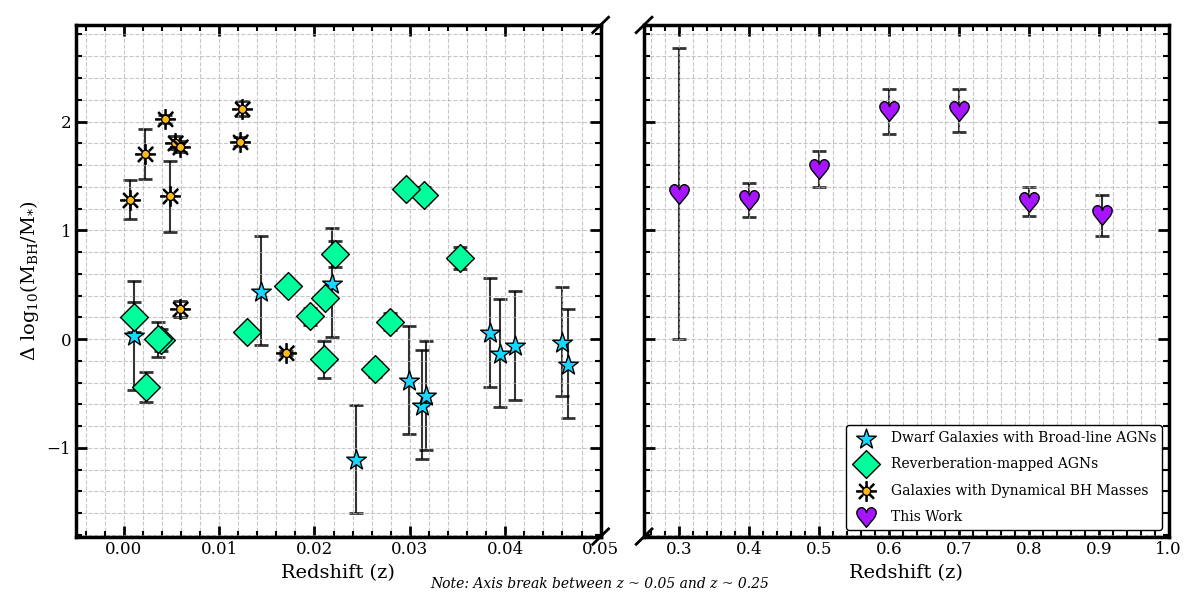

In [34]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]


# Your data using pre-calculated delta values (relative to scaling relation)
our_data = [
    {"name": "025_035", "redshift": 0.3, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035_Relation},
    {"name": "035_045", "redshift": 0.4, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_035_045_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_035_045_Relation},
    {"name": "045_055", "redshift": 0.5, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_045_055_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_045_055_Relation},
    {"name": "055_065", "redshift": 0.6, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_055_065_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_055_065_Relation},
    {"name": "065_075", "redshift": 0.7, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_065_075_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_065_075_Relation},
    {"name": "075_085", "redshift": 0.8, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_075_085_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_075_085_Relation},
    {"name": "085_096", "redshift": 0.905, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_085_096_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_085_096_Relation}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Calculate Delta log(MBH/Ms) relative to scaling relation
def calculate_delta_mass_ratio(data_list):
    x_vals = []
    y_vals = []
    y_err_vals = []
    
    # Scaling relation parameters
    alpha = 7.45
    beta = 1.05
    
    for data in data_list:
        x_vals.append(data["redshift"])
        
        # Calculate observed log(MBH/Ms)
        observed_mass_ratio = data["logMBH"] - data["logMs"]
        
        # Calculate expected log(MBH) from scaling relation
        # log(MBH/M☉) = α + β * log(Mstellar/10^11 M☉)
        # log(Mstellar/10^11 M☉) = log(Mstellar) - 11 = logMs - 11
        log_stellar_scaled = data["logMs"] - 11.0
        expected_log_MBH = alpha + beta * log_stellar_scaled
        
        # Calculate expected log(MBH/Ms)
        expected_mass_ratio = expected_log_MBH - data["logMs"]
        
        # Calculate delta: observed - expected
        delta_mass_ratio = observed_mass_ratio - expected_mass_ratio
        y_vals.append(delta_mass_ratio)
        
        # Error propagation: uncertainty remains the same for MBH
        y_err_vals.append(data["logMBH_uncertainty"])
    
    return x_vals, y_vals, y_err_vals

# Extract data for plotting
# For our data, use pre-calculated delta values directly
our_x = [data["redshift"] for data in our_data]
our_y = [data["delta_value"] for data in our_data]
our_y_err = [data["delta_uncertainty"] for data in our_data]

# For comparison data, calculate delta values using same reference
dwarf_x, dwarf_y, dwarf_y_err = calculate_delta_mass_ratio(dwarfGalaxiesWithBroadlineAGNs)
reverberation_x, reverberation_y, reverberation_y_err = calculate_delta_mass_ratio(reverberationMappedAGNs)
dynamical_x, dynamical_y, dynamical_y_err = calculate_delta_mass_ratio(galaxiesWithDynamicalBHMasses)

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)



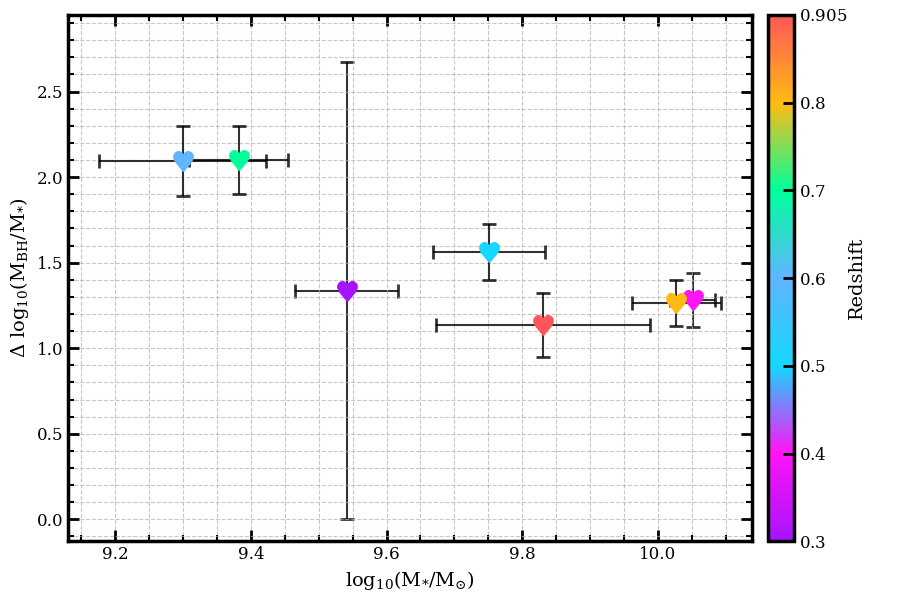

In [35]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(9, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Stellar Mass - Scaling Relation)
datasets = [
    ('025_035', 
    Stellar_Mass_Average_025_035,
    Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035_Relation,
    Stellar_Mass_SD_025_035,
    Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035_Relation), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    Stellar_Mass_Average_035_045,
    Delta_BH_Stellar_Broad_AGN_Only_035_045_Relation,
    Stellar_Mass_SD_035_045,
    Delta_BH_Stellar_Broad_AGN_Only_SD_035_045_Relation),
    ('045_055', 
    Stellar_Mass_Average_045_055,
    Delta_BH_Stellar_Broad_AGN_Only_045_055_Relation,
    Stellar_Mass_SD_045_055,
    Delta_BH_Stellar_Broad_AGN_Only_SD_045_055_Relation),
    ('055_065', 
    Stellar_Mass_Average_055_065,
    Delta_BH_Stellar_Broad_AGN_Only_055_065_Relation,
    Stellar_Mass_SD_055_065,
    Delta_BH_Stellar_Broad_AGN_Only_SD_055_065_Relation),
    ('065_075', 
    Stellar_Mass_Average_065_075,
    Delta_BH_Stellar_Broad_AGN_Only_065_075_Relation,
    Stellar_Mass_SD_065_075,
    Delta_BH_Stellar_Broad_AGN_Only_SD_065_075_Relation),
    ('075_085', 
    Stellar_Mass_Average_075_085,
    Delta_BH_Stellar_Broad_AGN_Only_075_085_Relation,
    Stellar_Mass_SD_075_085,
    Delta_BH_Stellar_Broad_AGN_Only_SD_075_085_Relation),
    ('085_096', 
    Stellar_Mass_Average_085_096,
    Delta_BH_Stellar_Broad_AGN_Only_085_096_Relation,
    Stellar_Mass_SD_085_096,
    Delta_BH_Stellar_Broad_AGN_Only_SD_085_096_Relation)
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, yerr) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr = yerr,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

## Configure legend with MNRAS style
#legend = ax.legend(
#    loc='lower left',
#    fontsize=12,
#    frameon=True,
#    fancybox=True,
#    shadow=True,
#    borderpad=0.8,
#    handletextpad=0.6,
#    columnspacing=1.0,
#    handlelength=1.0,
#    labelspacing=1.0,
#    numpoints=1
#)
#legend.get_frame().set_linewidth(1.5)
#legend.get_frame().set_edgecolor('black')

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=0)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096_Relation.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096_Relation.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


ANALYSIS RESULTS
Right Plot - Linear Fit Equation:
Δ log₁₀(M_BH/M_*) = (-0.387 ± 0.750) × z + (1.687 ± 0.510)
Slope: -0.387 ± 0.750
Intercept: 1.687 ± 0.510

Left Plot - Standard Deviation:
σ = 0.824
±1σ bounds: 0.824 and -0.824
R² = 0.000


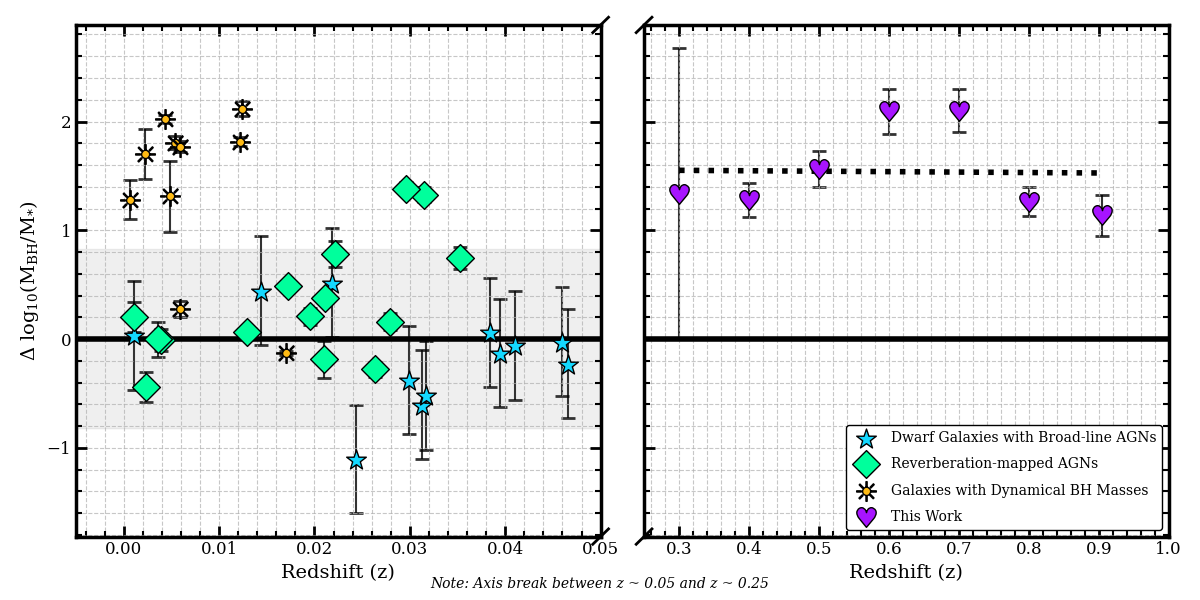

In [36]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]


# Your data using pre-calculated delta values (relative to scaling relation)
our_data = [
    {"name": "025_035", "redshift": 0.3, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035_Relation},
    {"name": "035_045", "redshift": 0.4, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_035_045_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_035_045_Relation},
    {"name": "045_055", "redshift": 0.5, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_045_055_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_045_055_Relation},
    {"name": "055_065", "redshift": 0.6, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_055_065_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_055_065_Relation},
    {"name": "065_075", "redshift": 0.7, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_065_075_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_065_075_Relation},
    {"name": "075_085", "redshift": 0.8, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_075_085_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_075_085_Relation},
    {"name": "085_096", "redshift": 0.905, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_085_096_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_085_096_Relation}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Calculate Delta log(MBH/Ms) relative to scaling relation
def calculate_delta_mass_ratio(data_list):
    x_vals = []
    y_vals = []
    y_err_vals = []
    
    # Scaling relation parameters
    alpha = 7.45
    beta = 1.05
    
    for data in data_list:
        x_vals.append(data["redshift"])
        
        # Calculate observed log(MBH/Ms)
        observed_mass_ratio = data["logMBH"] - data["logMs"]
        
        # Calculate expected log(MBH) from scaling relation
        # log(MBH/M☉) = α + β * log(Mstellar/10^11 M☉)
        # log(Mstellar/10^11 M☉) = log(Mstellar) - 11 = logMs - 11
        log_stellar_scaled = data["logMs"] - 11.0
        expected_log_MBH = alpha + beta * log_stellar_scaled
        
        # Calculate expected log(MBH/Ms)
        expected_mass_ratio = expected_log_MBH - data["logMs"]
        
        # Calculate delta: observed - expected
        delta_mass_ratio = observed_mass_ratio - expected_mass_ratio
        y_vals.append(delta_mass_ratio)
        
        # Error propagation: uncertainty remains the same for MBH
        y_err_vals.append(data["logMBH_uncertainty"])
    
    return x_vals, y_vals, y_err_vals

# Extract data for plotting
# For our data, use pre-calculated delta values directly
our_x = [data["redshift"] for data in our_data]
our_y = [data["delta_value"] for data in our_data]
our_y_err = [data["delta_uncertainty"] for data in our_data]

# For comparison data, calculate delta values using same reference
dwarf_x, dwarf_y, dwarf_y_err = calculate_delta_mass_ratio(dwarfGalaxiesWithBroadlineAGNs)
reverberation_x, reverberation_y, reverberation_y_err = calculate_delta_mass_ratio(reverberationMappedAGNs)
dynamical_x, dynamical_y, dynamical_y_err = calculate_delta_mass_ratio(galaxiesWithDynamicalBHMasses)

# Combine all left plot data for standard deviation calculation
all_left_y = dwarf_y + reverberation_y + dynamical_y
std_dev = np.std(all_left_y)

# Add y=0 reference lines for both plots
ax1.axhline(y=0, color='black', linestyle='-', linewidth=4, alpha=1.0, zorder=5)

# Add shaded region for ±1 standard deviation around zero
ax1.fill_between(x=np.arange(-0.50, 0.055, 0.001), y1 = -std_dev, y2 = std_dev, color='#3B3B3B', alpha=0.08)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=4, alpha=1.0, zorder=5)


# Fit a line to our data for the right plot
our_x_np = np.array(our_x)
our_y_np = np.array(our_y)
coeffs = np.polyfit(our_x_np, our_y_np, 1)  # Linear fit
fit_line = np.poly1d(coeffs)

# Create smooth line for the fit
x_fit = np.linspace(min(our_x), max(our_x), 100)
y_fit = fit_line(x_fit)

# Add trend line for our data (black dotted)
ax2.plot(x_fit, y_fit, color='black', linestyle=':', linewidth=4, alpha=1.0, zorder=5)

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Print the fit equation and standard deviation
print("=" * 50)
print("ANALYSIS RESULTS")
print("=" * 50)

# Calculate uncertainties for the fit coefficients
# Using weighted least squares approach considering error bars
weights = 1 / np.array(our_y_err)**2
fit_coeffs, cov_matrix = np.polyfit(our_x_np, our_y_np, 1, w=weights, cov=True)
slope, intercept = fit_coeffs
slope_err = np.sqrt(cov_matrix[0, 0])
intercept_err = np.sqrt(cov_matrix[1, 1])

print(f"Right Plot - Linear Fit Equation:")
print(f"Δ log₁₀(M_BH/M_*) = ({slope:.3f} ± {slope_err:.3f}) × z + ({intercept:.3f} ± {intercept_err:.3f})")
print(f"Slope: {slope:.3f} ± {slope_err:.3f}")
print(f"Intercept: {intercept:.3f} ± {intercept_err:.3f}")

print(f"\nLeft Plot - Standard Deviation:")
print(f"σ = {std_dev:.3f}")
print(f"±1σ bounds: {std_dev:.3f} and {-std_dev:.3f}")

# Calculate R-squared for goodness of fit
y_pred = fit_line(our_x_np)
ss_res = np.sum((our_y_np - y_pred) ** 2)
ss_tot = np.sum((our_y_np - np.mean(our_y_np)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R² = {r_squared:.3f}")

print("=" * 50)

plt.savefig('/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Delta_MM_Additional_data.png', dpi=300, bbox_inches='tight')

# Save and show the figure
plt.show(block=False)


Talk to cyanne about their trend line.
Send Karl the errors for the delta.
Include Kormendy and Ho

First data point stellar mass: 9.54128958166523
Best Fit: α = -6.60 ± 1.98, β = 1.36 ± 0.20
Kormendy & Ho (2013): log₁₀(M_BH) = 8.69 + 1.16 × log₁₀(M_bulge/10¹¹ M_☉)
Matt et al. (2025): log₁₀(M_BH) = 8.69 + 1.17 × log₁₀(M_bulge/10¹¹ M_☉)


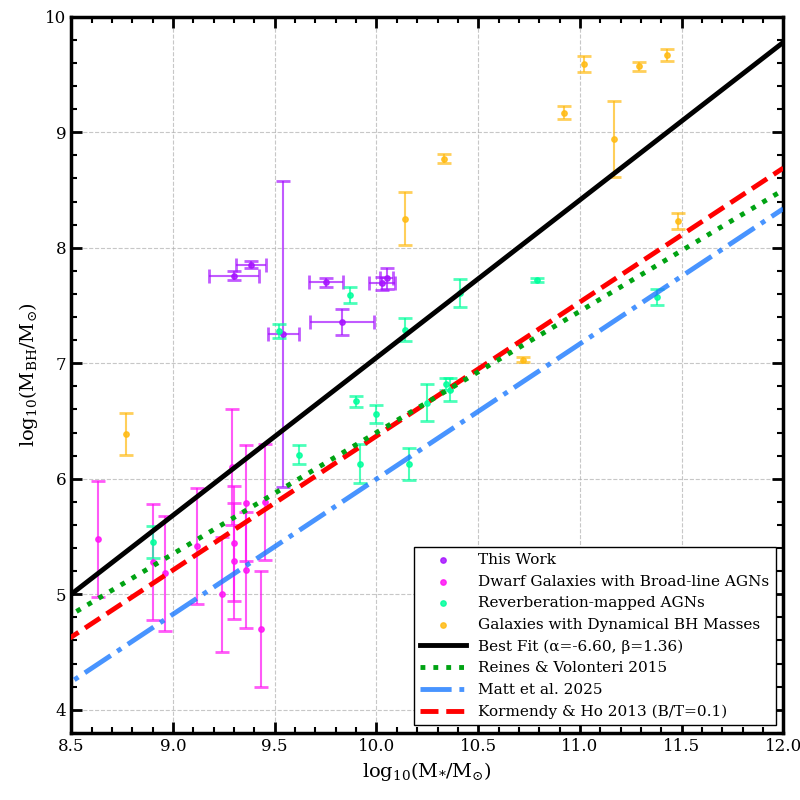

In [37]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.optimize import curve_fit

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23}, 
]

# Your variables are already defined in your environment - using them directly
# No need to redefine them here

OurData = [
    {"name": "025_035", "logMs": Stellar_Mass_Average_025_035, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035), "logMs_uncertainty": Stellar_Mass_SD_025_035, "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_AGN_Only_Mean_025_035*np.log(10))},
    {"name": "035_045", "logMs": Stellar_Mass_Average_035_045, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045), "logMs_uncertainty": Stellar_Mass_SD_035_045, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_035_045*np.log(10))},
    {"name": "045_055", "logMs": Stellar_Mass_Average_045_055, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055), "logMs_uncertainty": Stellar_Mass_SD_045_055, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_045_055*np.log(10))},
    {"name": "055_065", "logMs": Stellar_Mass_Average_055_065, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065), "logMs_uncertainty": Stellar_Mass_SD_055_065, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_055_065*np.log(10))},
    {"name": "065_075", "logMs": Stellar_Mass_Average_065_075, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075), "logMs_uncertainty": Stellar_Mass_SD_065_075, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_065_075*np.log(10))},
    {"name": "075_085", "logMs": Stellar_Mass_Average_075_085, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_075_085), "logMs_uncertainty": Stellar_Mass_SD_075_085, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096*np.log(10))},
    {"name": "085_096", "logMs": Stellar_Mass_Average_085_096, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096), "logMs_uncertainty": Stellar_Mass_SD_085_096, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_AGN_Only_Mean_085_096*np.log(10))}
]

print(f"First data point stellar mass: {Stellar_Mass_Average_025_035}")

# Create single panel figure
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='white')

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]
heart_color = "#a714ff"

# Extract data for plotting
ourdata_x = [galaxy["logMs"] for galaxy in OurData]
ourdata_y = [galaxy["logMBH"] for galaxy in OurData]
ourdata_x_err = [galaxy["logMs_uncertainty"] for galaxy in OurData]
ourdata_y_err = [galaxy["logMBH_uncertainty"] for galaxy in OurData]

dwarf_x = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y_err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

reverberation_x = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]
reverberation_y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
reverberation_y_err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

dynamical_x = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y_err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

# Combine all data for fitting
all_x = dwarf_x + reverberation_x + dynamical_x + ourdata_x
all_y = dwarf_y + reverberation_y + dynamical_y + ourdata_y
all_y_err = dwarf_y_err + reverberation_y_err + dynamical_y_err + ourdata_y_err
all_x = np.array(all_x)
all_y = np.array(all_y)
all_y_err = np.array(all_y_err)

# Define power law functions
def power_law_10_11(x, alpha, beta):
    return alpha + beta * (x - 11.0)

def power_law(x, alpha, beta):
    return alpha + beta * x

# Perform fitting
try:
    popt, pcov = curve_fit(power_law, all_x, all_y, absolute_sigma=True)
    alpha_fit, beta_fit = popt
    alpha_err, beta_err = np.sqrt(np.diag(pcov))
    fit_successful = True
except:
    fit_successful = False

# Create x values for lines
x_fit = np.linspace(8.0, 12.0, 100)

# Reference line parameters
alpha_ref_Reines = 7.45
beta_ref_Reines = 1.05

# Kormendy & Ho (2013) parameters
alpha_ref_KormenlyHo = 8.69
beta_ref_KormenlyHo = 1.16

# Matt et al. 2025 parameters
alpha0_matt = 8.69
beta0_matt = 1.17
alpha_z_matt = 1.04
alpha_z_err_matt = 0.5

# Define Matt et al. 2025 relation
def matt_relation_stellar(log_m_star, bulge_fraction=0.1):
    """
    Convert Matt et al. 2025 relation to stellar mass basis
    Assumes M_bulge = bulge_fraction * M_star
    """
    # Convert stellar mass to bulge mass
    log_m_bulge = np.log10(bulge_fraction) + log_m_star
    
    # Apply Matt et al. relation: log(M_BH) = alpha0 + beta0 * log(M_bulge/10^11)
    log_m_bh = alpha0_matt + beta0_matt * (log_m_bulge - 11.0)
    
    return log_m_bh

# Plot all data points
ax.scatter(ourdata_x, ourdata_y,
          color=heart_color, s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='This Work')
ax.errorbar(ourdata_x, ourdata_y,
           yerr=ourdata_y_err, xerr=ourdata_x_err,
           linestyle='', ecolor=heart_color,
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot dwarf galaxies
ax.scatter(dwarf_x, dwarf_y,
          color="#ff14f5", s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='Dwarf Galaxies with Broad-line AGNs')
ax.errorbar(dwarf_x, dwarf_y,
           yerr=dwarf_y_err, linestyle='', ecolor="#ff14f5",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot reverberation-mapped AGNs
ax.scatter(reverberation_x, reverberation_y,
          color=dataset_colors[4], s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='Reverberation-mapped AGNs')
ax.errorbar(reverberation_x, reverberation_y,
           yerr=reverberation_y_err, linestyle='', ecolor=dataset_colors[4],
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot galaxies with dynamical BH masses
ax.scatter(dynamical_x, dynamical_y,
          color=dataset_colors[5], s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='Galaxies with Dynamical BH Masses')
ax.errorbar(dynamical_x, dynamical_y,
           yerr=dynamical_y_err, linestyle='', ecolor=dataset_colors[5],
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot best fit line in red
if fit_successful:
    y_fit = power_law(x_fit, alpha_fit, beta_fit)
    ax.plot(x_fit, y_fit, color='black', linewidth=3.5, zorder=30,
            label=f'Best Fit (α={alpha_fit:.2f}, β={beta_fit:.2f})')

# Plot Reines line in navy
y_ref_Reines = power_law_10_11(x_fit, alpha_ref_Reines, beta_ref_Reines)
ax.plot(x_fit, y_ref_Reines, color='#00a313', linewidth=3.5, linestyle=":", 
         label='Reines & Volonteri 2015', zorder=29)

# Add Matt et al. 2025 relation
# Plot for different bulge fractions to show range
matt_bulge_fractions = [0.05, 0.15]  # Show range with two bulge fractions
matt_alphas = [0.8, 0.4]

for i, bf in enumerate(matt_bulge_fractions):
    y_matt = matt_relation_stellar(x_fit, bulge_fraction=bf)
    if i == 0:  # Only label the first one
        ax.plot(x_fit, y_matt, color="#1A79FF", linewidth=3.5, 
                 linestyle='-.', alpha=matt_alphas[i],
                 label='Matt et al. 2025', zorder=28)

# Fill between the two Matt relations to show uncertainty range
y_matt_low = matt_relation_stellar(x_fit, bulge_fraction=0.05)
y_matt_high = matt_relation_stellar(x_fit, bulge_fraction=0.15)

# Add Kormendy & Ho line
bulge_fractions = [0.10]
kormendy_colors = ['red']
kormendy_linestyles = ['--']

for i, bf in enumerate(bulge_fractions):
    y_ref_KormendyHo_scaled = alpha_ref_KormenlyHo + beta_ref_KormenlyHo * (np.log10(bf) + x_fit - 11)
    ax.plot(x_fit, y_ref_KormendyHo_scaled, 
             color=kormendy_colors[i], linewidth=3.5,
             linestyle=kormendy_linestyles[i], 
             label=f'Kormendy & Ho 2013 (B/T={bf})', 
             zorder=28 - i)

# Configure the plot
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")
ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')
ax.tick_params(top=True, right=True)
ax.set_ylim(3.0, 10.5)

# Create legend
legend = ax.legend(loc='lower right', fontsize=11, 
                  frameon=True, fancybox=False, 
                  edgecolor='black', facecolor='white', framealpha=1.0, 
                  ncol=1, columnspacing=0.9, handlelength=3, borderpad=0.4)

# Adjust layout
plt.tight_layout(pad=1.0)

# Print fit results
if fit_successful:
    print(f"Best Fit: α = {alpha_fit:.2f} ± {alpha_err:.2f}, β = {beta_fit:.2f} ± {beta_err:.2f}")
else:
    print("Fit failed")

print(f"Kormendy & Ho (2013): log₁₀(M_BH) = {alpha_ref_KormenlyHo} + {beta_ref_KormenlyHo} × log₁₀(M_bulge/10¹¹ M_☉)")
print(f"Matt et al. (2025): log₁₀(M_BH) = {alpha0_matt} + {beta0_matt} × log₁₀(M_bulge/10¹¹ M_☉)")

ax.set_xlim(8.5, 12.0)
ax.set_ylim(3.8, 10)

fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_Trends.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show(block=False)


In [38]:
aaaaaaa

NameError: name 'aaaaaaa' is not defined

In [ ]:
pdf_filename = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/Figures_For_Stella_Mass.pdf"
with PdfPages(pdf_filename) as pdf:
    figures = [plt.figure(n) for n in plt.get_fignums()]
    print(plt.get_fignums())
    for fig in figures:
        pdf.savefig(fig)
    plt.close('all')
print(f"All figures saved to {pdf_filename}")

In [ ]:
L_3000_Mean_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Narrow_Sigma_025_035
L_3000_Mean_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Narrow_Sigma_SD_025_035
L_3000_Mean_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
L_3000_Mean_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_025_035_Mean
L_3000_Mean_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_025_035_Mean_SD
L_3000_Mean_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_Mean
L_3000_Mean_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_Mean_SD
L_3000_Mean_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_Mean
L_3000_Mean_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_Mean_SD
L_3000_Mean_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_Mean
L_3000_Mean_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_Mean_SD
L_3000_Mean_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_Mean
L_3000_Mean_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_Mean_SD
L_3000_Mean_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_Mean
L_3000_Mean_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_Mean_SD
L_3000_Mean_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_Mean
L_3000_Mean_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_Mean_SD
L_3000_Mean_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096
Stellar_Mass_Average_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
Stellar_Mass_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
Stellar_Mass_Average_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
Stellar_Mass_SD_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
Stellar_Mass_Average_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
Stellar_Mass_SD_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
Stellar_Mass_Average_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
Stellar_Mass_SD_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
Stellar_Mass_Average_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
Stellar_Mass_SD_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
Stellar_Mass_Average_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
Stellar_Mass_SD_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
Stellar_Mass_Average_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
Stellar_Mass_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096
Delta_BH_Stellar_Broad_FeII_Removed_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
Delta_BH_Stellar_Broad_FeII_Removed_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
Delta_BH_Stellar_Broad_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
Delta_BH_Stellar_Broad_SD_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
Delta_BH_Stellar_Broad_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
Delta_BH_Stellar_Broad_SD_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
Delta_BH_Stellar_Broad_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
Delta_BH_Stellar_Broad_SD_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
Delta_BH_Stellar_Broad_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
Delta_BH_Stellar_Broad_SD_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
Delta_BH_Stellar_Broad_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
Delta_BH_Stellar_Broad_SD_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
Delta_BH_Stellar_Broad_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
Delta_BH_Stellar_Broad_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
Stellar_Mass_Average_025_035
Stellar_Mass_SD_025_035
Stellar_Mass_Average_035_045
Stellar_Mass_SD_035_045
Stellar_Mass_Average_045_055
Stellar_Mass_SD_045_055
Stellar_Mass_Average_055_065
Stellar_Mass_SD_055_065
Stellar_Mass_Average_065_075
Stellar_Mass_SD_065_075
Stellar_Mass_Average_075_085
Stellar_Mass_SD_075_085
Stellar_Mass_Average_085_096
Stellar_Mass_SD_085_096
Stellar_Mass_Average_025_035
Delta_BH_Stellar_Broad_FeII_Removed_025_035
Stellar_Mass_SD_025_035
Delta_BH_Stellar_Broad_FeII_Removed_SD_025_035
Stellar_Mass_Average_035_045
Delta_BH_Stellar_Broad_035_045
Stellar_Mass_SD_035_045
Delta_BH_Stellar_Broad_SD_035_045
Stellar_Mass_Average_045_055
Delta_BH_Stellar_Broad_045_055
Stellar_Mass_SD_045_055
Delta_BH_Stellar_Broad_SD_045_055
Stellar_Mass_Average_055_065
Delta_BH_Stellar_Broad_055_065
Stellar_Mass_SD_055_065
Delta_BH_Stellar_Broad_SD_055_065
Stellar_Mass_Average_065_075
Delta_BH_Stellar_Broad_065_075
Stellar_Mass_SD_065_075
Delta_BH_Stellar_Broad_SD_065_075
Stellar_Mass_Average_075_085
Delta_BH_Stellar_Broad_075_085
Stellar_Mass_SD_075_085
Delta_BH_Stellar_Broad_SD_075_085
Stellar_Mass_Average_085_096
Delta_BH_Stellar_Broad_085_096
Stellar_Mass_SD_085_096
Delta_BH_Stellar_Broad_SD_085_096
Stellar_Mass_Average_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035
Stellar_Mass_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035
Stellar_Mass_Average_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045
Stellar_Mass_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045
Stellar_Mass_Average_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055
Stellar_Mass_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055
Stellar_Mass_Average_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065
Stellar_Mass_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065
Stellar_Mass_Average_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075
Stellar_Mass_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075
Stellar_Mass_Average_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085
Stellar_Mass_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085
Stellar_Mass_Average_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096
Stellar_Mass_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096
Delta_BH_Stellar_Broad_FeII_Removed_025_035
Delta_BH_Stellar_Broad_FeII_Removed_SD_025_035
Delta_BH_Stellar_Broad_035_045
Delta_BH_Stellar_Broad_SD_035_045
Delta_BH_Stellar_Broad_045_055
Delta_BH_Stellar_Broad_SD_045_055
Delta_BH_Stellar_Broad_055_065
Delta_BH_Stellar_Broad_SD_055_065
Delta_BH_Stellar_Broad_065_075
Delta_BH_Stellar_Broad_SD_065_075
Delta_BH_Stellar_Broad_075_085
Delta_BH_Stellar_Broad_SD_075_085
Delta_BH_Stellar_Broad_085_096
Delta_BH_Stellar_Broad_SD_085_096
Stellar_Mass_Average_025_035
Delta_BH_Stellar_Broad_FeII_Removed_025_035_Relation
Stellar_Mass_SD_025_035
Delta_BH_Stellar_Broad_FeII_Removed_SD_025_035_Relation
Stellar_Mass_Average_035_045
Delta_BH_Stellar_Broad_035_045_Relation
Stellar_Mass_SD_035_045
Delta_BH_Stellar_Broad_SD_035_045_Relation
Stellar_Mass_Average_045_055
Delta_BH_Stellar_Broad_045_055_Relation
Stellar_Mass_SD_045_055
Delta_BH_Stellar_Broad_SD_045_055_Relation
Stellar_Mass_Average_055_065
Delta_BH_Stellar_Broad_055_065_Relation
Stellar_Mass_SD_055_065
Delta_BH_Stellar_Broad_SD_055_065_Relation
Stellar_Mass_Average_065_075
Delta_BH_Stellar_Broad_065_075_Relation
Stellar_Mass_SD_065_075
Delta_BH_Stellar_Broad_SD_065_075_Relation
Stellar_Mass_Average_075_085
Delta_BH_Stellar_Broad_075_085_Relation
Stellar_Mass_SD_075_085
Delta_BH_Stellar_Broad_SD_075_085_Relation
Stellar_Mass_Average_085_096
Delta_BH_Stellar_Broad_085_096_Relation
Stellar_Mass_SD_085_096
Delta_BH_Stellar_Broad_SD_085_096_Relation
Stellar_Mass_Average_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035
Stellar_Mass_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Mean_025_035
Stellar_Mass_Average_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045
Stellar_Mass_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_035_045
Stellar_Mass_Average_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055
Stellar_Mass_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_045_055
Stellar_Mass_Average_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065
Stellar_Mass_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_055_065
Stellar_Mass_Average_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075
Stellar_Mass_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_065_075
Stellar_Mass_Average_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085
Stellar_Mass_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_075_085
Stellar_Mass_Average_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096
Stellar_Mass_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Mean_085_096



AGN_Only_Continuum_L3000_025_035
AGN_Only_Continuum_L_3000_SD_025_035
AGN_Only_Continuum_L3000_035_045
AGN_Only_Continuum_L_3000_SD_035_045
AGN_Only_Continuum_L3000_045_055
AGN_Only_Continuum_L_3000_SD_045_055
AGN_Only_Continuum_L3000_055_065
AGN_Only_Continuum_L_3000_SD_055_065
AGN_Only_Continuum_L3000_065_075
AGN_Only_Continuum_L_3000_SD_065_075
AGN_Only_Continuum_L3000_075_085
AGN_Only_Continuum_L_3000_SD_075_085
AGN_Only_Continuum_L3000_085_096
AGN_Only_Continuum_L_3000_SD_085_096
AGN_Only_Continuums_L3000_025_035
AGN_Only_Continuums_L3000_SD_025_035
AGN_Only_Continuums_L3000_035_045
AGN_Only_Continuums_L3000_SD_035_045
AGN_Only_Continuums_L3000_045_055
AGN_Only_Continuums_L3000_SD_045_055
AGN_Only_Continuums_L3000_055_065
AGN_Only_Continuums_L3000_SD_055_065
AGN_Only_Continuums_L3000_065_075
AGN_Only_Continuums_L3000_SD_065_075
AGN_Only_Continuums_L3000_075_085
AGN_Only_Continuums_L3000_SD_075_085
AGN_Only_Continuums_L3000_085_096
AGN_Only_Continuums_L3000_SD_085_096